# Chapter 22. Statistics Without Fooling Yourself

*The runnable half of this chapter.* Every code cell below is the chapter's own code, and the words around it are the chapter's own explanation. Run the cells in order: each one uses names made by the cells before it.

Riverstone Supplies is the single worked example throughout the book, so the data here is the same data you meet in every other chapter.

Built from `manuscript/ch22-statistics-without-fooling-yourself.md`.

# Chapter 22. Statistics Without Fooling Yourself

*Part 2 — The Analyst*

> **Chapter at a glance**
>
> **You will learn to:** turn sampling error into a confidence interval, for a mean and for a proportion, by hand, in a spreadsheet and in Python, and explain what it does and doesn't mean · state a hypothesis, run the right test, and read a p-value without overclaiming · design an A/B test: what to measure, how many people you need, when to stop · see why peeking at a running test manufactures winners · handle multiple comparisons and recognize p-hacking in your own work · separate correlation from causation, and spot confounders, Simpson's paradox, survivorship bias, and regression to the mean · weigh statistical significance against practical significance · write up a result plainly, including the ones that didn't work · fit and read a straight-line regression by hand, in a spreadsheet and in Python.
>
> **Before you start:** Chapter 21 (distributions, sampling, standard error, Bayes), Chapter 18 (pandas and matplotlib), and Chapter 15 (scatter plots, trend lines, and showing uncertainty). Chapter 4's percentages and Chapter 14's data quality both matter: no test survives bad data.
>
> **Time needed:** 20–23 hours, spread over two and a half weeks, in two parts. Part A, "Uncertainty and tests" (sections 22.1–22.4), takes about 11 hours and ends with a checkpoint. Part B, "Traps and relationships" (sections 22.5–22.10), takes about 10 hours; the regression section 22.10 alone is about 4 of them. Allow 2 more for the project.
>
> **Tools:** Python 3.14 in the virtual environment from Chapter 17, with `pandas`, `numpy`, `scipy` (installed in Chapter 21), `matplotlib`, and `statsmodels` (installed in section 22.2). This chapter's code was checked on Python 3.11.15 with pandas 3.0.6, numpy 2.4.6, scipy 1.17.1, statsmodels 0.15.0, and matplotlib 3.10.8. A spreadsheet (Excel or Google Sheets) does the by-hand sums with `NORM.S.INV`, `CONFIDENCE.T`, `SLOPE`, `INTERCEPT`, and `RSQ`.
>
> **Practice data:** Chapter 21's `delivery_times_2025.csv`, plus `companion/ch22/`: `ab_test_2026.csv` (an A/B test of two subject lines on Riverstone's February 2026 offer email, 8,400 recipients), `transporters_q4_2025.csv` (11,600 Q4 deliveries by transporter and route), and `ch22_by_hand.xlsx` (the spreadsheet versions of the chapter's by-hand sums). The two CSV files are invented for this chapter; Riverstone's ERP has neither campaign nor transporter data. Run this chapter's notebook from the `companion/ch22/` folder. The code reads Chapter 21's file as `"../ch21/delivery_times_2025.csv"`, where `../` means "up one folder", so the path reads "up to `companion/`, then into `ch21`".

---

## Why this matters

Chapter 21 gave you the tools. This chapter is about the ways those tools go wrong in the hands of people who mean well, which includes you and me.

The pattern is always the same. Someone measures two things, sees a difference, and explains it. The explanation is plausible, the slide is clear, and the difference was noise. Or the difference was real and tiny, and the company spends ₹40 lakh chasing it. Or the difference was real and caused by something nobody put on the slide.

Analysts are *paid* to tell the difference. It's the one part of the job that a dashboard cannot do for you: deciding whether a number means anything. Get it right and you become the person whose numbers people trust when the room disagrees. Get it wrong twice in public and you are the person who "made that chart".

Everything here is testable on Riverstone's data, and most of it is simulated rather than asserted: when the chapter says peeking at a test inflates false positives, it runs 4,500 simulated tests (1,500 for each way of checking) and counts.

---

## In plain English

You taste a spoonful of dal and decide the whole pot needs salt. That's statistics: a sample, a judgment about the pot, and a risk of being wrong.

Three things can go wrong, and they map onto the whole chapter.

- **The spoon was small.** One spoonful from a big pot might not be typical. That's sampling error, and a **confidence interval** is your way of saying "the pot is somewhere between this salty and that salty".
- **You stirred after tasting the first pot and not the second.** Now you're comparing a well-mixed pot with a settled one. That's a **confounder**: the thing you didn't control explains the difference you saw.
- **You kept tasting until it tasted how you hoped.** Taste twenty times and one spoonful will be unusual. That's **peeking and p-hacking**, and it's the most common way honest analysts produce false findings.

The discipline is not "be more careful". It's a small set of habits: decide what you'll measure before you look, quantify uncertainty every time, and ask what else could explain the number.

The chapter has two parts. **Part A** (sections 22.1–22.4) is about uncertainty and tests: how sure can you be of a number, and is a difference real? **Part B** (sections 22.5–22.10) is about traps and relationships: confounders, biased samples, and, at the end, fitting a straight line through two measures.

---

## 22.1 Confidence intervals

A sample mean or a sample percentage is an **estimate**: your best guess at a number you can't see directly. A **confidence interval** is that estimate plus the range of values that are consistent with it, given how much samples wobble.

### The recipe, by hand

Every confidence interval in this chapter has the same shape:

**estimate ± multiplier × standard error**

- The **estimate** is the number from your sample.
- The **standard error** (Chapter 21, section 21.8) is how much that estimate would typically change from one sample to the next.
- The **multiplier** says how many standard errors to go each side. For 95% confidence it's about 1.96. Chapter 21's 68–95–99.7 rule (section 21.5) says 95% of a normal distribution lies within about 2 standard deviations of its centre; 1.96 is the exact figure. The part added and subtracted, multiplier × standard error, is the **margin of error**.

Start with a percentage, because the arithmetic is shortest. A survey of 400 customers finds 62% satisfied.

> **The formula: an interval for a proportion.** p̂ ± 1.96 × √(p̂ × (1 − p̂) ÷ *n*)
>
> - **p̂** ("p-hat") is the proportion in your sample: successes ÷ *n*. The hat means "estimated from a sample".
> - ***n*** is the sample size.
> - **√(p̂ × (1 − p̂) ÷ *n*)** is the standard error of a proportion. It is largest when p̂ is 0.5 and shrinks as *n* grows.

By hand, one step at a time:

1. p̂ = 0.62 and *n* = 400.
2. Standard error = √(0.62 × 0.38 ÷ 400) = √0.000589 = **0.0243**.
3. Margin of error = 1.96 × 0.0243 = **0.0476**, about 4.8 points.
4. Interval = 0.62 − 0.0476 to 0.62 + 0.0476 = **0.572 to 0.668**, or **57.2% to 66.8%**.

So the honest report is "62% satisfied, give or take about five points (95% interval 57% to 67%), from 400 customers".

### The same in a spreadsheet

Type 400 in `B2` and 0.62 in `B3`, then:

**The chapter's output:**

```
B4  =SQRT(B3*(1-B3)/B2)      standard error        0.0243
B5  =NORM.S.INV(0.975)       the multiplier        1.96
B6  =B5*B4                   margin of error       0.0476
B7  =B3-B6                   lower end             0.572
B8  =B3+B6                   upper end             0.668
```

`NORM.S.INV(0.975)` asks the standard normal distribution for the value with 97.5% of it below: 2.5% is left in the top tail and, by symmetry, 2.5% in the bottom one, which leaves 95% in the middle. It's the spreadsheet cousin of Chapter 21's `NORM.INV` and scipy's `ppf`. The *Interval* sheet of `ch22_by_hand.xlsx` holds these formulas, and they work the same in Excel and Google Sheets.

### Intervals for a mean, and the t-distribution

For a mean, the standard error is the sample standard deviation divided by √*n*, exactly as in Chapter 21. The multiplier changes slightly.

> **The formula: an interval for a mean.** x̄ ± *t** × *s* ÷ √*n*
>
> - **x̄** is the sample mean, and ***s*** the sample standard deviation.
> - ***s* ÷ √*n*** is the standard error of the mean.
> - ***t**** ("t-star") is the multiplier from the **t-distribution** with *n* − 1 **degrees of freedom**.

The **t-distribution** is a bell curve like the normal, but a little wider, with fatter tails. It's wider because *s* is itself estimated from the sample, which adds a little uncertainty of its own, so the interval must stretch slightly to stay right 95% of the time. **Degrees of freedom** measure how much information went into *s*: *n* − 1, for the same reason the sample variance divides by *n* − 1 (Chapter 21, section 21.2). With 200 orders, *t** is 1.972 instead of 1.960; with 20 it's 2.093. For large samples the two are the same for practical purposes.

In a spreadsheet, `=CONFIDENCE.T(0.05, sd, n)` returns the margin of error for a mean directly: 0.05 is 1 − 0.95, sd is the sample standard deviation, and n is the count. `=CONFIDENCE.NORM` does the same with 1.96 in place of *t**. For the sample below (standard deviation ₹17,862 from 200 orders), `=CONFIDENCE.T(0.05,17862,200)` gives **₹2,491**, and `=T.INV.2T(0.05,199)` gives the multiplier 1.972. Both are in the *Interval* sheet.

Now in Python, in three cells. First, draw a sample of 200 orders from the 45,040 in Chapter 21's file, the way section 21.8 did:

> **Fresh start.** The cells below do not depend on the ones above. If you have been running top to bottom, restarting the kernel here changes nothing.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

deliveries = pd.read_csv("../ch21/delivery_times_2025.csv", parse_dates=["order_date"])
population = deliveries["order_value"]
rng = np.random.default_rng(22)
sample = pd.Series(rng.choice(population, size=200, replace=False))
print(f"sample of {len(sample)} orders: mean ₹{sample.mean():,.0f}, standard deviation ₹{sample.std(ddof=1):,.0f}")

sample of 200 orders: mean ₹23,280, standard deviation ₹17,862


How it works:

- `pd.read_csv(..., parse_dates=["order_date"])` reads the file and turns the `order_date` column into real dates (Chapter 18). The path starts with `../` because the notebook runs in `companion/ch22/`.
- `rng.choice(population, size=200, replace=False)` picks 200 different orders at random, with the seeded generator from Chapter 21 (seed 22), so you get the same sample every time. Wrapping it in `pd.Series(...)` gives it pandas' `.mean()` and `.std()`.
- `sample.std(ddof=1)` is the sample standard deviation, dividing by *n* − 1 (section 21.2).

Second, the interval by the formula, one quantity per line:

In [2]:
mean = sample.mean()
sd = sample.std(ddof=1)
se = sd / np.sqrt(len(sample))
t_star = stats.t.ppf(0.975, df=len(sample) - 1)
lo = mean - t_star * se
hi = mean + t_star * se
print(f"standard error ₹{se:,.0f}, t* = {t_star:.3f}, margin ₹{t_star * se:,.0f}")
print(f"95% interval   ₹{lo:,.0f} to ₹{hi:,.0f}")

standard error ₹1,263, t* = 1.972, margin ₹2,491
95% interval   ₹20,789 to ₹25,771


- `se = sd / np.sqrt(len(sample))` is *s* ÷ √*n*.
- `stats.t.ppf(0.975, df=len(sample) - 1)` is *t**: the value of the t-distribution with 199 degrees of freedom that has 97.5% below it. It's `ppf` from section 21.5, for the t-distribution instead of the normal. The spreadsheet's `T.INV.2T(0.05,199)` gives the same 1.972.
- `lo` and `hi` are the two ends: estimate minus and plus the margin. The margin matches the spreadsheet's `CONFIDENCE.T`.

Third, the one-line version, and a check against the truth. Here, unusually, the whole population is in the file, so you can see whether the interval caught the real mean:

In [3]:
lo_scipy, hi_scipy = stats.t.interval(0.95, df=len(sample) - 1, loc=mean, scale=se)
print(f"scipy's interval ₹{lo_scipy:,.0f} to ₹{hi_scipy:,.0f}")
true_mean = population.mean()
print(f"the true mean    ₹{true_mean:,.0f}  (inside the interval: {lo <= true_mean <= hi})")

scipy's interval ₹20,789 to ₹25,771
the true mean    ₹24,840  (inside the interval: True)


- `stats.t.interval(0.95, df=..., loc=..., scale=...)` does the second cell in one call. Its four settings are the **confidence level** (0.95), the **degrees of freedom**, the centre of the interval (`loc`, the sample mean), and the standard error (`scale`). It returns the two ends, which `lo_scipy, hi_scipy = ...` unpacks.
- `lo <= true_mean <= hi` reads "is the true mean between `lo` and `hi`?"; Python lets you chain the two comparisons like that. It prints `True` or `False`.

### What happens if you change it

Before you run the next cell, predict: will a 99% interval be wider or narrower than the 95% one?

In [4]:
lo_99, hi_99 = stats.t.interval(0.99, df=len(sample) - 1, loc=mean, scale=se)
print(f"99% interval ₹{lo_99:,.0f} to ₹{hi_99:,.0f}")

99% interval ₹19,995 to ₹26,565


Wider. To be right more often, the interval must cover more ground: the multiplier grows from 1.972 to about 2.60. Confidence costs width, and the only way to get both more confidence and a narrow interval is a bigger sample.

### What it means, and what it doesn't

![Sixty horizontal confidence intervals from sixty samples of 200 orders, with a vertical line at the true mean; the few intervals that miss it are drawn in red and labelled "misses"](figures/fig22-1-confidence-intervals.svg)

*Figure 22.1 — Each line is one sample's 95% interval. The method is right 95% of the time; any single interval either contains the truth or doesn't.*

- **Correct:** "If we repeated this sampling many times, 95% of the intervals we built this way would contain the true mean."
- **Wrong:** "There's a 95% probability the true mean is in *this* interval." The true mean is a fixed number; it's the interval that's random. (Bayesian statistics does let you make the first kind of statement, with a different machinery and a prior; Chapter 21's Bayes' rule is the entry point.)
- **Also wrong:** "95% of orders fall in this range." That's a percentile range and it's much wider. Confidence intervals are about the *estimate*, not the data.

### Intervals for proportions, in Python

Most business tests are about rates: open rate, conversion, on-time percentage. Here is the proportion formula from the start of this section, applied to all 45,040 deliveries:

In [5]:
on_time = deliveries["on_time"]
n = len(on_time)
successes = int(on_time.sum())
p_hat = successes / n
se_p = np.sqrt(p_hat * (1 - p_hat) / n)
print(f"on-time rate {p_hat*100:.2f}% from {n:,} orders")
print(f"normal approximation: {(p_hat - 1.96*se_p)*100:.2f}% to {(p_hat + 1.96*se_p)*100:.2f}%")

on-time rate 81.76% from 45,040 orders
normal approximation: 81.41% to 82.12%


- `on_time.sum()` counts the `True` values, because Python treats `True` as 1 and `False` as 0. `int(...)` makes it a plain whole number.
- `p_hat` and `se_p` are p̂ and its standard error, line for line as in the formula box. This interval is called the **normal approximation**, because it treats p̂ as normally distributed.

The normal approximation is fine for big samples and rates well away from 0% and 100%. When *n* is small, or the rate is close to 0 or 1 (a 2% order rate from 150 recipients, say), it can even run below 0%. The **Wilson interval** is a corrected version that behaves well in those cases and never leaves the 0–100% range. You don't need its formula; scipy has it:

In [6]:
test = stats.binomtest(successes, n)
wilson_lo, wilson_hi = test.proportion_ci(confidence_level=0.95, method="wilson")
print(f"Wilson interval:      {wilson_lo*100:.2f}% to {wilson_hi*100:.2f}%")

Wilson interval:      81.40% to 82.12%


- `stats.binomtest(k, n)` builds a test object for *k* successes in *n* trials. It's really a hypothesis test (section 22.2), but here we only want its interval.
- `.proportion_ci(...)` is a **method** of that object: a function that belongs to it, called with a dot. It returns the interval's two ends.
- `confidence_level=0.95` sets the confidence (0.95 is also its default, but saying it makes the code readable); `method="wilson"` chooses Wilson.

With 45,040 rows, the two intervals agree to 0.01 points. The difference matters for small groups, so use Wilson for one branch:

In [7]:
kolkata = deliveries[deliveries["branch"] == "Kolkata"]["on_time"]
k_test = stats.binomtest(int(kolkata.sum()), len(kolkata))
k_lo, k_hi = k_test.proportion_ci(confidence_level=0.95, method="wilson")
print(f"Kolkata: {kolkata.mean()*100:.2f}% ({k_lo*100:.2f}% to {k_hi*100:.2f}%) from {len(kolkata):,} orders")

Kolkata: 68.15% (66.92% to 69.35%) from 5,626 orders


The filter `deliveries[deliveries["branch"] == "Kolkata"]["on_time"]` keeps Kolkata's rows, then its `on_time` column (Chapter 18). The rest repeats the previous cell.

With 45,040 orders the company interval is ±0.4 points, so the on-time figure is precise. With a sample of 200 it would be ±5 points, which is the difference between "we're at 82%" and "we're somewhere between 77% and 87%". **Report the interval whenever the number comes from a sample**, and especially when someone is about to compare it with a target.

### Comparing two rates

Section 22.2 compares two open rates. The interval for the difference between two proportions adds the two squared standard errors under one square root:

> **The formula: an interval for a difference of two proportions.** (p̂<sub>B</sub> − p̂<sub>A</sub>) ± 1.96 × √(p̂<sub>A</sub>(1 − p̂<sub>A</sub>) ÷ *n*<sub>A</sub> + p̂<sub>B</sub>(1 − p̂<sub>B</sub>) ÷ *n*<sub>B</sub>)
>
> - **p̂<sub>A</sub>** and **p̂<sub>B</sub>** are the two groups' rates; ***n*<sub>A</sub>** and ***n*<sub>B</sub>** their sizes.
> - Each term under the root is one group's squared standard error. Uncertainties add as squares, not as plain numbers, which is why the root goes round the sum.

> **Watch out: precision is not accuracy.** A confidence interval measures sampling error only. It says nothing about a biased sample, a broken query, or the 100 customers with no city. Chapter 14's checks come first; the interval is the last step, not the first.

---

## 22.2 Hypothesis tests and p-values

A **hypothesis test** asks: if there were no real difference, how likely is a result at least as extreme as the one I saw?

- **The null hypothesis (H₀)** is the boring claim: the two subject lines have the same open rate; the branches have the same on-time rate.
- **The alternative (H₁)** is that they differ.
- **The p-value** is the probability of seeing your result, or one more extreme, *if the null were true*.
- **Significance level (α)**, usually 0.05, is the false-positive rate you accept before you look.
- **The effect size** is how big the difference is, in units people understand: "3.45 points more opens", "0.66 days faster". The test says whether a difference is likely to be real; the effect size says whether it's worth caring about.

A **two-sided test** asks "is there any difference, in either direction?"; a **one-sided test** asks only "is B better?". This book uses two-sided tests. That's why the multiplier is 1.96: the 5% of surprising results is split, 2.5% in each tail.

### The A/B test

Riverstone tested two subject lines on its February 2026 offer email: 4,200 recipients each, chosen at random. Before the test, the marketing team wrote down its **primary metric**, the one number the decision would rest on: the **open rate**, because the goal of this email was reach. Order rate and revenue per recipient would be reported as secondary metrics.

First, look at the file:

In [8]:
ab = pd.read_csv("ab_test_2026.csv")
print(ab.head())
print(ab.shape)

   recipient_id variant  opened  ordered  order_value
0             1       A    True    False          0.0
1             2       A    True    False          0.0
2             3       A   False    False          0.0
3             4       A   False    False          0.0
4             5       A   False    False          0.0
(8400, 5)


One row per recipient: which `variant` they got, whether they `opened` the email and `ordered`, and the `order_value` (0 for everyone who didn't order). `ab.shape` gives rows and columns: 8,400 recipients, 5 columns.

Now one summary row per variant:

In [9]:
summary = (ab.groupby("variant")
             .agg(sent=("opened", "size"), opens=("opened", "sum"),
                  orders=("ordered", "sum"), revenue=("order_value", "sum")))
summary["open_rate"] = (summary["opens"] / summary["sent"] * 100).round(2)
summary["order_rate"] = (summary["orders"] / summary["sent"] * 100).round(2)
summary["revenue_per_recipient"] = (summary["revenue"] / summary["sent"]).round(2)
print(summary.to_string())

         sent  opens  orders    revenue  open_rate  order_rate  revenue_per_recipient
variant                                                                              
A        4200    987      83  2031550.0      23.50        1.98                 483.70
B        4200   1132      97  2227300.0      26.95        2.31                 530.31


- `.agg(sent=("opened", "size"), ...)` is Chapter 18's named aggregation: each new column is (source column, function). **`size` counts the rows in each group, whatever column you name**, so `("opened", "size")` is simply "how many recipients"; `"sum"` on a True/False column counts the `True`s.
- The three rates are divided by `sent`; the two percentages are multiplied by 100 and rounded to 2 decimals.
- `print(summary.to_string())` prints every column. A plain `print(summary)` would hide the middle columns behind `...` when the table is wider than the screen.

Variant B was opened more often. Is that real?

### The chi-square test, by hand first

Set the opens out as a 2×2 table of **observed** counts:

| | Opened | Not opened | Total |
|---|---|---|---|
| A | 987 | 3,213 | 4,200 |
| B | 1,132 | 3,068 | 4,200 |
| Total | 2,119 | 6,281 | 8,400 |

Now pretend the null is true: the subject line makes no difference. Then both variants share one open rate, the pooled one: 2,119 ÷ 8,400 = 25.23%. Each variant would **expect** 25.23% of its 4,200 to open, which is 1,059.5, and 3,140.5 not to. An **expected count** is always (row total × column total) ÷ grand total: 4,200 × 2,119 ÷ 8,400 = 1,059.5.

The **chi-square statistic** (χ², "kai-square") adds up how far each observed count is from its expected count, scaled by the expected count:

**χ² = Σ (O − E)² ÷ E**, where O is an observed count, E its expected count, and Σ means "add up over all four cells".

| Cell | O | E | (O − E)² ÷ E |
|---|---:|---:|---:|
| A, opened | 987 | 1,059.5 | 4.961 |
| A, not opened | 3,213 | 3,140.5 | 1.674 |
| B, opened | 1,132 | 1,059.5 | 4.961 |
| B, not opened | 3,068 | 3,140.5 | 1.674 |
| **Total** | | | **13.27** |

A χ² of 0 would mean the observed table matches the no-difference table exactly; the bigger it gets, the less the null fits. How big is surprising depends on the table's **degrees of freedom**: once the totals are fixed, only one cell of a 2×2 table is free to vary (fill in one and the other three follow), so df = 1. For one degree of freedom, a χ² above 3.84 happens less than 5% of the time by chance. 13.27 is far beyond it.

In a spreadsheet, put the observed counts in one 2×2 range and the expected counts in another; `=CHISQ.TEST(observed, expected)` returns the p-value directly.

In Python, build the observed table straight from the data with `pd.crosstab` (Chapter 21), which counts rows for each combination of two columns:

In [10]:
from scipy.stats import chi2_contingency

opens_table = pd.crosstab(ab["variant"], ab["opened"])
print(opens_table)

opened   False  True 
variant              
A         3213    987
B         3068   1132


The rows are the variants and the columns are `opened` = `False` and `True`: the same four counts as the hand table.

In [11]:
chi2, p_open, dof, expected = chi2_contingency(opens_table, correction=False)
print(f"chi-square = {chi2:.2f}, degrees of freedom = {dof}, p-value = {p_open:.4f}")
print("expected counts if there were no difference:")
print(expected)

chi-square = 13.27, degrees of freedom = 1, p-value = 0.0003
expected counts if there were no difference:
[[3140.5 1059.5]
 [3140.5 1059.5]]


- `chi2_contingency(table, correction=False)` runs the test and returns four things, which `chi2, p_open, dof, expected = ...` unpacks: the statistic, the p-value, the degrees of freedom, and the expected table. The expected table matches the hand calculation, 1,059.5 and 3,140.5.
- `correction=False` turns off **Yates' continuity correction**, a small adjustment scipy applies to 2×2 tables by default. Without it, the result is exactly the two-proportion z-test below (z² = χ²) and matches the hand sum. With samples this size the correction barely matters.

Then the effect size and its interval, with the difference formula from section 22.1. Everything stays in proportions until it's printed:

In [12]:
n_a = opens_table.loc["A"].sum()
n_b = opens_table.loc["B"].sum()
p_a = opens_table.loc["A", True] / n_a
p_b = opens_table.loc["B", True] / n_b
diff = p_b - p_a
se_diff = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)
print(f"open rate: A {p_a*100:.2f}%, B {p_b*100:.2f}%, difference {diff*100:+.2f} points")
print(f"95% interval for the difference: {(diff - 1.96*se_diff)*100:+.2f} to {(diff + 1.96*se_diff)*100:+.2f} points")

open rate: A 23.50%, B 26.95%, difference +3.45 points
95% interval for the difference: +1.60 to +5.31 points


- `opens_table.loc["A"].sum()` adds row A across both columns: A's recipients. `opens_table.loc["A", True]` is the single cell "A, opened".
- `se_diff` is the square-root part of the formula, one term per variant. The `+` in `{...:+.2f}` prints a sign even for positive numbers.

The whole interval sits above zero: B's advantage is somewhere between about 1.6 and 5.3 points. That is the same conclusion as the p-value, in a far more useful form.

### Installing statsmodels: the z-test

The **two-proportion z-test** asks the same question another way: how many standard errors apart are the two rates? It lives in **statsmodels**, a library of statistical models and tests that Chapter 30 and Part 4 use heavily. In a terminal, with your virtual environment active (Chapter 17), install it:

**`bash`, not run by this notebook.** Run it in the tool the chapter names.

```bash
python -m pip install statsmodels
```

Then, in the notebook:

In [13]:
from statsmodels.stats.proportion import proportions_ztest

z, p_z = proportions_ztest([1132, 987], [4200, 4200])
print(f"z = {z:.2f}, p-value = {p_z:.4f}, z squared = {z**2:.2f}")

z = 3.64, p-value = 0.0003, z squared = 13.27


- `from statsmodels.stats.proportion import proportions_ztest` loads one function from the library's `stats.proportion` part.
- `proportions_ztest([1132, 987], [4200, 4200])` takes a list of success counts (B's opens, A's opens) and a list of group sizes, and returns the z statistic and its p-value.
- z = 3.64 means the two rates are 3.64 standard errors apart; its square is the chi-square statistic, 13.27, and the p-values are identical. For a 2×2 table the two tests are one test written two ways.

### Orders and revenue: the secondary metrics

In [14]:
orders_table = pd.crosstab(ab["variant"], ab["ordered"])
chi2_o, p_order, _, _ = chi2_contingency(orders_table, correction=False)
rev_a = summary.loc["A", "revenue_per_recipient"]
rev_b = summary.loc["B", "revenue_per_recipient"]
print(f"order rate: A {summary.loc['A', 'order_rate']}%, B {summary.loc['B', 'order_rate']}%")
print(f"chi-square p-value: {p_order:.4f}")
print(f"revenue per recipient: A ₹{rev_a:,.2f}, B ₹{rev_b:,.2f}")

order rate: A 1.98%, B 2.31%
chi-square p-value: 0.2915
revenue per recipient: A ₹483.70, B ₹530.31


- The same test on the `ordered` column. The `_` names catch the two results we don't need (degrees of freedom and the expected table); `_` is Python's convention for "a value I'm ignoring".
- `rev_a` and `rev_b` are looked up first, so the `print` line stays short.

![Two histograms of differences under the null, with the observed open-rate gap far into the tail and the observed order-rate gap near the middle](figures/fig22-2-null-distribution.svg)

*Figure 22.2 — What chance alone produces, and where the observed difference sits. Left: the open-rate gap is hard to explain by chance. Right: the order-rate gap is ordinary.*

So: **B wins on the primary metric, opens, and not on orders.** The honest conclusion is "the new subject line gets more people to open the email, and we have no evidence it sells more". Revenue per recipient is higher for B too, but it's the same handful of orders (about 2 recipients in 100) spread over everyone, so it's even noisier than the order rate. That's why it was a secondary metric.

### What a p-value is not

| People say | It actually means |
|---|---|
| "p = 0.03, so there's a 3% chance the null is true" | No. It's the probability of the data given the null, not the null given the data (Chapter 21, section 21.7) |
| "p = 0.20, so there's no difference" | No. Absence of evidence isn't evidence of absence, especially in a small test |
| "p = 0.001, so the effect is big" | No. With enough data, a trivial difference gets a tiny p-value |
| "p = 0.049 significant, p = 0.051 not" | The threshold is a convention, not a law of nature. Report the number and the interval |

**Report the effect size and its interval first, the p-value second.** "B's open rate is 3.45 points higher (95% interval: 1.6 to 5.3 points), p = 0.0003" tells a reader everything; "significant at p < 0.05" tells them almost nothing.

### Choosing a test

| Question | Test | In Python |
|---|---|---|
| Two proportions (open rate A vs B) | Chi-square, or a two-proportion z-test | `chi2_contingency`; `proportions_ztest` from `statsmodels.stats.proportion` |
| Two means, roughly normal or large samples | Welch's two-sample t-test | `stats.ttest_ind(a, b, equal_var=False)` |
| Two means, skewed data or small samples | Mann-Whitney U, or a bootstrap | `stats.mannwhitneyu`, or resampling |
| Before and after, same units | Paired t-test | `stats.ttest_rel` |
| More than two groups | ANOVA, then pairwise with a correction | `stats.f_oneway` |
| Categories against categories | Chi-square | `chi2_contingency` |

Two of these compare delivery times between branches:

- **Welch's t-test** compares two means. It's the t-distribution from section 22.1 again: the difference in means divided by its standard error. `equal_var=False` means "don't assume the two groups have the same spread", which is the safe choice and the reason it carries Welch's name.
- **The Mann-Whitney U test** puts all the values from both groups in one ranked list and asks whether one group's values tend to rank higher. It doesn't use the values themselves, only their order, so a few huge values can't dominate it.

In [15]:
mumbai = deliveries[deliveries["branch"] == "Mumbai HO"]["delivery_days"]
bengaluru = deliveries[deliveries["branch"] == "Bengaluru"]["delivery_days"]

t_stat, p_t = stats.ttest_ind(mumbai, bengaluru, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(mumbai, bengaluru)
print(f"means: Mumbai {mumbai.mean():.2f} days, Bengaluru {bengaluru.mean():.2f} days")
print(f"Welch t-test p = {p_t:.3g}")
print(f"Mann-Whitney p = {p_u:.3g}")
print(f"difference in medians: {bengaluru.median() - mumbai.median():.1f} days")

means: Mumbai 3.51 days, Bengaluru 4.17 days
Welch t-test p = 1.93e-197
Mann-Whitney p = 0
difference in medians: 0.6 days


Two things in that output need translating:

- **1.93e-197** is scientific notation: 1.93 × 10⁻¹⁹⁷, a decimal point followed by 196 zeros and then 193. The `:.3g` format prints three significant figures and switches to this notation for very small or very large numbers.
- **p = 0** is not a true zero. The number is smaller than the computer can store, so it rounds to 0. No real p-value is exactly 0.

Neither is how you'd report it. Report tiny p-values as "p < 0.001":

In [16]:
for name, p in [("Welch t-test", p_t), ("Mann-Whitney", p_u)]:
    print(name, "p < 0.001" if p < 0.001 else f"p = {p:.3f}")

Welch t-test p < 0.001
Mann-Whitney p < 0.001


The `for` loop walks through a list of (name, p-value) pairs; `"p < 0.001" if p < 0.001 else ...` is Python's one-line if/else (Chapter 17), which picks the report format.

Both tests agree here, which is the usual outcome when the difference is real and the samples are large. The Mann-Whitney is the safer choice on skewed data because it compares ranks rather than means.

### The bootstrap

The **bootstrap** gives an interval for almost any statistic, including a median, without a formula. The idea: your sample is your best picture of the population, so draw many new samples *from your sample*, recompute the statistic each time, and see how much it moves. Each new sample is drawn **with replacement** (an order can be picked more than once) and is the same size as the original; that's what makes each one a little different.

In [17]:
rng = np.random.default_rng(2202)
median_gaps = []
for _ in range(10_000):
    resample_m = rng.choice(mumbai, size=len(mumbai), replace=True)
    resample_b = rng.choice(bengaluru, size=len(bengaluru), replace=True)
    median_gaps.append(np.median(resample_b) - np.median(resample_m))
boot_lo, boot_hi = np.percentile(median_gaps, [2.5, 97.5])
print(f"bootstrap 95% interval for the gap in medians: {boot_lo:.1f} to {boot_hi:.1f} days")

bootstrap 95% interval for the gap in medians: 0.6 to 0.7 days


- `rng.choice(mumbai, size=len(mumbai), replace=True)` draws a resample of Mumbai's delivery times, the same size as the original, **with replacement**. `replace=True` is the whole trick; with `replace=False` you'd get the same values back, shuffled.
- The loop runs 10,000 times (`10_000` is 10,000; Python ignores the underscore) and keeps each gap in medians in the list `median_gaps`.
- `np.percentile(median_gaps, [2.5, 97.5])` finds the values with 2.5% and 97.5% of the gaps below them: the middle 95% of the resampled gaps is the interval. It takes a few seconds to run.

Bengaluru's median delivery time is 0.6 to 0.7 days longer than Mumbai HO's, the same answer the two tests pointed to, now as a size with an interval. It works on skewed data because it never assumes a shape; the resamples inherit whatever shape the data has.

---

## 22.3 Designing an A/B test

Running the test is the simple part. The design is where it's won or lost.

**1. Decide the metric before you look.** One primary metric, chosen for the decision you'll make. Riverstone's email test named *open rate*, because the goal was reach; had the goal been sales, it should have named *revenue per recipient*. Choosing afterwards is how you always find a winner.

**2. Work out the sample size you need.** Every test can go wrong in two ways:

- A **type I error** is a false positive: declaring a difference that isn't there. Its rate is α, usually 0.05.
- A **type II error** is a false negative: missing a difference that is there. **Power** is the chance of *not* making one, the chance of detecting a real effect of a given size. It's usually set at 0.80, so the type II error rate is 1 − 0.80 = 0.20.

For a proportion, the sample size needs the baseline rate, the smallest difference worth detecting (the **minimum detectable effect**), α, and power:

> **The formula: sample size per variant for two proportions.**
> *n* = [ z<sub>α/2</sub> × √(2 p̄(1 − p̄)) + z<sub>β</sub> × √(p₁(1 − p₁) + p₂(1 − p₂)) ]² ÷ (p₂ − p₁)²
>
> - **p₁** is the baseline rate and **p₂** the rate you want to be able to detect; p₂ − p₁ is the minimum detectable effect.
> - **p̄** ("p-bar") is their average, (p₁ + p₂) ÷ 2.
> - **z<sub>α/2</sub>** is the multiplier for α, two-sided: 1.960 for α = 0.05, from `NORM.S.INV(0.975)`. It's α/2 because the 5% is split between two tails.
> - **z<sub>β</sub>** is the multiplier for power: 0.842 for 80% power, from `NORM.S.INV(0.8)`.

By hand, for an open rate of 24% and a hoped-for 27%:

1. p₁ = 0.24, p₂ = 0.27, p̄ = 0.255, and p₂ − p₁ = 0.03.
2. First term: 1.960 × √(2 × 0.255 × 0.745) = 1.960 × 0.6164 = 1.2081.
3. Second term: 0.842 × √(0.24 × 0.76 + 0.27 × 0.73) = 0.842 × 0.6160 = 0.5185.
4. Add and square: (1.2081 + 0.5185)² = 2.9811.
5. Divide by 0.03² = 0.0009: 2.9811 ÷ 0.0009 = 3,312.4, and round **up** to **3,313 per variant**. You can't send an email to 0.4 of a person, and rounding down would leave the test slightly short of its power.

The *SampleSize* sheet of `ch22_by_hand.xlsx` does the same with `NORM.S.INV` and `ROUNDUP`. In Python, the formula becomes a function you can reuse:

In [18]:
def sample_size_for_proportion(baseline, lift_points, alpha=0.05, power=0.80):
    """Recipients needed per variant to detect an absolute lift, in percentage points."""
    p1 = baseline
    p2 = baseline + lift_points / 100
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)
    p_bar = (p1 + p2) / 2
    numerator = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2))) ** 2
    return int(np.ceil(numerator / (p2 - p1) ** 2))

for lift in (1, 2, 3, 5):
    print(f"to detect a {lift}-point lift on a 24% open rate: {sample_size_for_proportion(0.24, lift):>7,} per variant")
for lift in (0.2, 0.5, 1.0):
    print(f"to detect a {lift}-point lift on a 2% order rate:  {sample_size_for_proportion(0.02, lift):>7,} per variant")

to detect a 1-point lift on a 24% open rate:  29,036 per variant
to detect a 2-point lift on a 24% open rate:   7,358 per variant
to detect a 3-point lift on a 24% open rate:   3,313 per variant
to detect a 5-point lift on a 24% open rate:   1,222 per variant
to detect a 0.2-point lift on a 2% order rate:   80,682 per variant
to detect a 0.5-point lift on a 2% order rate:   13,809 per variant
to detect a 1.0-point lift on a 2% order rate:    3,826 per variant


What each line does:

- `baseline` is p₁ as a proportion (0.24); `lift_points` is the lift in percentage points (3), so `p2 = baseline + lift_points / 100` is 0.27.
- `alpha=0.05` and `power=0.80` are **default arguments**: used unless you pass something else.
- `stats.norm.ppf(1 - alpha/2)` is z<sub>α/2</sub> = `ppf(0.975)` = 1.960, and `stats.norm.ppf(power)` is z<sub>β</sub> = 0.842: the same numbers as `NORM.S.INV`.
- `numerator` is the squared bracket of the formula; `np.ceil(...)` rounds **up** to the next whole number, and `int(...)` makes it a whole-number type.
- `{...:>7,}` right-aligns the number in 7 characters with thousands commas, so the column lines up.

The 3-point row reproduces the hand answer, 3,313.

That table is the single most useful thing in this chapter for a working analyst. It also answers the question the other way round: with the 4,200 per variant Riverstone actually had, what's the smallest lift the test could reliably detect? Try lifts in steps of 0.01 points until the sample size needed falls to 4,200:

In [19]:
def minimum_detectable_lift(baseline, n_per_variant):
    lift = 0.01
    while sample_size_for_proportion(baseline, lift) > n_per_variant:
        lift = lift + 0.01
    return round(lift, 2)

print(f"with 4,200 per variant: opens {minimum_detectable_lift(0.24, 4200)} points, orders {minimum_detectable_lift(0.02, 4200)} points")

with 4,200 per variant: opens 2.66 points, orders 0.95 points


- The `while` loop keeps adding 0.01 points while the test would still need more than 4,200 recipients, and stops at the first lift it could detect with 80% power.
- `round(lift, 2)` tidies the tiny rounding errors that repeated adding of 0.01 leaves behind.

So Riverstone's 4,200 per variant could detect about a 2.7-point difference in opens and nothing smaller than about 0.95 points in orders: fine for the first question, hopeless for the second. **Knowing this before the test means you either run it longer, or you don't pretend the order-rate result means anything.**

**3. Randomize properly.** Split at the level of the thing you're measuring, usually the customer, and make the split random. Splitting by branch, by day, or by "whoever was in the first half of the list" bakes in a confounder.

**4. Run it for a whole number of business cycles.** A week captures Monday behaviour and Saturday behaviour; three days captures whatever those three days were.

**5. Decide the stopping rule in advance.** This is the subject of the next section.

**6. Write the plan down before starting.** Metric, sample size, duration, stopping rule, and what decision each outcome leads to. Writing the plan down before any data arrives is called **pre-registration**. A page is enough, and it's the difference between a test and a story.

---

## 22.4 Peeking, p-hacking, and multiple comparisons

### Peeking

The tempting behaviour: check the dashboard every day, stop when it's significant. Here's what that does, with two **identical** variants and no real difference at all. Build it in three steps.

First, simulate one variant's opens. `rng.random(4000)` makes 4,000 random numbers between 0 and 1; each is below 0.25 with probability 0.25, so `< 0.25` turns them into 4,000 True/False values in which about a quarter are `True`, "opened":

In [20]:
rng = np.random.default_rng(7)
a = rng.random(4000) < 0.25
print(a[:10])
print(f"open rate {a.mean():.4f}")

[False False False  True False False  True False False False]
open rate 0.2450


`a[:10]` shows the first ten recipients (slicing, Chapter 17), and `a.mean()` is the share of `True`s. It's close to 0.25, but not exactly: that's sampling error.

Second, make an identical variant B and test once, at the end, with the z formula from section 22.1: the difference divided by its standard error, compared with 1.96:

In [21]:
b = rng.random(4000) < 0.25
pa, pb = a.mean(), b.mean()
se = np.sqrt(pa*(1-pa)/4000 + pb*(1-pb)/4000)
z = (pa - pb) / se
print(f"A {pa:.4f}, B {pb:.4f}, z = {z:.2f}, declared a winner: {abs(z) > 1.96}")

A 0.2450, B 0.2537, z = -0.90, declared a winner: False


`abs(z)` drops the sign, because a difference in either direction counts (a two-sided test). Here there's no winner, as there shouldn't be.

Third, wrap it in a function that repeats this many times and can check at several points along the way, stopping at the first "win":

In [22]:
def peeking_false_positive_rate(peeks, rng, trials=1500, n_max=4000, p=0.25):
    """Two identical variants. How often does checking `peeks` times declare a winner?"""
    checkpoints = np.linspace(n_max / peeks, n_max, peeks).astype(int)
    false_positives = 0
    for _ in range(trials):
        a = rng.random(n_max) < p
        b = rng.random(n_max) < p
        for c in checkpoints:
            pa, pb = a[:c].mean(), b[:c].mean()
            se = np.sqrt(pa*(1-pa)/c + pb*(1-pb)/c)
            if se > 0 and abs(pa - pb) / se > 1.96:
                false_positives += 1
                break
    return false_positives / trials * 100

rng = np.random.default_rng(2223)
for peeks in (1, 5, 20):
    print(f"checking {peeks:>2} time(s): {peeking_false_positive_rate(peeks, rng):.1f}% of identical pairs declared a winner")

checking  1 time(s): 4.9% of identical pairs declared a winner


checking  5 time(s): 14.3% of identical pairs declared a winner


checking 20 time(s): 23.9% of identical pairs declared a winner


What each line does:

- `peeks` is how many times you look; `rng` is the random generator, passed in so the function doesn't depend on a variable outside it. `trials=1500` pairs of identical variants are simulated per setting, each with up to `n_max=4000` recipients and a true open rate `p=0.25`.
- `np.linspace(n_max / peeks, n_max, peeks)` makes `peeks` evenly spaced checkpoints ending at 4,000: with 5 peeks, 800, 1,600, 2,400, 3,200, and 4,000. `.astype(int)` turns them into whole numbers, because you can't slice at recipient 800.0.
- For each checkpoint `c`, `a[:c]` is the first `c` recipients: what the dashboard would show on that day. The test is the same z as in the second cell.
- `break` stops checking this pair at the first "win", as a person would: they'd declare the winner and stop the test. `false_positives += 1` counts it.
- The result is the percentage of the 1,500 pairs declared a winner. The whole run takes a few seconds.

![A bar chart: checking once gives 4.9% false winners, five times 14.3%, twenty times 23.9%, against a 5% line](figures/fig22-3-peeking.svg)

*Figure 22.3 — 4,500 simulated tests of two identical variants, 1,500 for each way of checking. The more often you check, the more often chance hands you a "winner".*

Checking once behaves as advertised: about 5% false positives. Checking twenty times nearly quintuples it. The fix is not "don't look" — it's **decide the sample size in advance and test once at the end**, or use a method designed for continuous monitoring (sequential testing, or a Bayesian approach with a stopping rule you set beforehand).

### Multiple comparisons

The same arithmetic applies to testing many things at once. Test 20 independent hypotheses at α = 0.05 and the chance of at least one false positive is 1 − 0.95²⁰ = 64%. That chance, of at least one false positive anywhere in a family of tests, is the **family-wise error rate**.

In [23]:
for k in (1, 5, 10, 20, 50):
    print(f"{k:>2} independent tests at α=0.05: P(at least one false positive) = {1 - 0.95**k:.1%}")

p_values = [0.001, 0.012, 0.030, 0.041, 0.048, 0.20, 0.31]
bonferroni = 0.05 / len(p_values)
print(f"\nBonferroni threshold for {len(p_values)} tests: {bonferroni:.4f}")
print("survive Bonferroni:", [p for p in p_values if p < bonferroni])

 1 independent tests at α=0.05: P(at least one false positive) = 5.0%
 5 independent tests at α=0.05: P(at least one false positive) = 22.6%
10 independent tests at α=0.05: P(at least one false positive) = 40.1%
20 independent tests at α=0.05: P(at least one false positive) = 64.2%
50 independent tests at α=0.05: P(at least one false positive) = 92.3%

Bonferroni threshold for 7 tests: 0.0071
survive Bonferroni: [0.001]


- `0.95**k` is the chance that all *k* tests stay quiet; one minus it is the chance that at least one doesn't. `:.1%` prints a proportion as a percentage with one decimal.
- `"\n"` at the start of a string prints a blank line first.
- The **Bonferroni correction** divides α by the number of tests, here 0.05 ÷ 7 = 0.0071, and keeps only the p-values below it. The list comprehension `[p for p in p_values if p < bonferroni]` (Chapter 17) keeps them.

Bonferroni is simple and strict. **Benjamini-Hochberg** (BH) is kinder when you're screening many things. Instead of the family-wise error rate, it controls the **false discovery rate**: the expected share of false positives among the findings you keep. By hand: sort the *m* p-values from smallest to largest, give each a rank *i*, and compare it with its own threshold, *i* ÷ *m* × 0.05. Find the largest rank whose p-value is at or under its threshold, and keep that one and every smaller one.

| Rank *i* | p-value | Threshold *i* ÷ 7 × 0.05 | At or under? |
|---:|---:|---:|---|
| 1 | 0.001 | 0.0071 | yes |
| 2 | 0.012 | 0.0143 | yes |
| 3 | 0.030 | 0.0214 | no |
| 4 | 0.041 | 0.0286 | no |
| 5 | 0.048 | 0.0357 | no |
| 6 | 0.20 | 0.0429 | no |
| 7 | 0.31 | 0.0500 | no |

The largest rank that passes is 2, so BH keeps two findings where Bonferroni keeps one. In Python:

In [24]:
ranked = sorted(p_values)
m = len(ranked)
largest = 0
for i, p in enumerate(ranked, start=1):
    if p <= i / m * 0.05:
        largest = i
print("survive Benjamini-Hochberg:", ranked[:largest])

survive Benjamini-Hochberg: [0.001, 0.012]


- `sorted(p_values)` returns the p-values in increasing order.
- `enumerate(ranked, start=1)` hands out each p-value with its rank, counting from 1 instead of Python's usual 0.
- `largest` remembers the last rank that passed its threshold; `ranked[:largest]` keeps everything up to it.

In business analysis the practical version is: *if you sliced the data twenty ways and one slice was significant, treat it as a hypothesis for a new test, not as a finding.*

### p-hacking, without meaning to

The garden of forking paths is a series of small, reasonable decisions that each nudge the answer:

- Trying three metrics and reporting the one that worked.
- Removing outliers only when it helps.
- Adding a week because the result "hasn't settled".
- Splitting by segment after seeing the overall result was flat.
- Choosing a different test after the first one gave p = 0.08.

None of these feels dishonest. Together they turn a 5% false-positive rate into something much worse. The defences are boring and effective: **write the analysis plan first**, **report everything you tried**, and **keep confirmatory analysis separate from exploration**. Exploration is valuable; it produces hypotheses, not conclusions.

### Checkpoint: the end of Part A

Before Part B, check that intervals and tests are yours. Take fifteen minutes, with a pencil and a calculator. Two versions of a delivery-feedback text message went to 1,000 customers each: 300 replied to version A and 345 to version B.

1. Work out each reply rate and the 95% interval for the difference B − A, with the formula from section 22.1.
2. Build the 2×2 table of observed counts, work out the expected counts, and compute χ² by hand. Is it above 3.84?
3. Check both in Python with `chi2_contingency(..., correction=False)`. (Answers at the end of the chapter.)

---

## 22.5 Correlation, causation, and confounders

**Correlation** measures how closely two measures follow a straight line together, from −1 to +1 (Chapter 15, section 15.6, used `CORREL` to get it). +1 is a perfect rising line, 0 is no straight-line pattern, and −1 is a perfect falling line.

### Correlation by hand

Take six customers, with small, made-up numbers so the arithmetic fits on a page: x is the number of orders each placed in a year, and y is their revenue in ₹ thousand. Section 22.10 fits a line through these same six.

| Customer | x (orders) | y (₹ thousand) | x − x̄ | y − ȳ | (x − x̄)(y − ȳ) | (x − x̄)² | (y − ȳ)² |
|---|---:|---:|---:|---:|---:|---:|---:|
| 1 | 2 | 55 | −4.5 | −105.83 | 476.25 | 20.25 | 11,200.69 |
| 2 | 4 | 90 | −2.5 | −70.83 | 177.08 | 6.25 | 5,017.36 |
| 3 | 5 | 140 | −1.5 | −20.83 | 31.25 | 2.25 | 434.03 |
| 4 | 7 | 160 | 0.5 | −0.83 | −0.42 | 0.25 | 0.69 |
| 5 | 9 | 230 | 2.5 | 69.17 | 172.92 | 6.25 | 4,784.03 |
| 6 | 12 | 290 | 5.5 | 129.17 | 710.42 | 30.25 | 16,684.03 |
| **Sum** | 39 | 965 | 0 | 0 | **1,567.50** | **65.50** | **38,120.83** |

The means are x̄ = 39 ÷ 6 = 6.5 orders and ȳ = 965 ÷ 6 = 160.83. When a customer is above average on both, or below average on both, the product (x − x̄)(y − ȳ) is positive; when they're above on one and below on the other, it's negative. Adding the products up says which happens more.

> **The formula: Pearson's correlation.** r = Σ(x − x̄)(y − ȳ) ÷ √[Σ(x − x̄)² × Σ(y − ȳ)²]
>
> The top is the sum of products from the table. The bottom scales it, so r always lands between −1 and +1, whatever the units.

Here r = 1,567.50 ÷ √(65.50 × 38,120.83) = 1,567.50 ÷ 1,580.16 = **0.992**: the six sit very close to a rising line. Check it:

In [25]:
x = np.array([2, 4, 5, 7, 9, 12])
y = np.array([55, 90, 140, 160, 230, 290])
print(f"r = {stats.pearsonr(x, y).statistic:.3f}")

r = 0.992


`np.array([...])` turns a list into a NumPy **array**, a list of numbers you can do arithmetic on all at once. `stats.pearsonr(x, y)` returns a result with two parts, the correlation `.statistic` and a p-value `.pvalue` for the test "is the true correlation zero?". In a spreadsheet, `=CORREL(A2:A7,B2:B7)` gives the same 0.992.

### On Riverstone's customers

Now the real thing: one row per customer, from Chapter 21's delivery data, with their number of orders, their total revenue, and their average delivery time.

In [26]:
by_customer = (deliveries.groupby("customer_id")
               .agg(orders=("order_id", "count"), revenue=("order_value", "sum"),
                    avg_days=("delivery_days", "mean")))
print(f"{len(by_customer):,} customers")
print(by_customer.corr().round(3))

4,596 customers
          orders  revenue  avg_days
orders     1.000    0.915    -0.086
revenue    0.915    1.000    -0.071
avg_days  -0.086   -0.071     1.000


- `groupby("customer_id")` makes one group per customer (`customer_id` is the customer who placed each order, Chapter 21), and the named aggregation counts their orders, adds their order values, and averages their delivery days.
- `.corr()` computes r for every pair of columns at once: a **correlation matrix**. Each column correlates perfectly with itself (1.000 on the diagonal), and the table is symmetric.

![Left: a scatter plot of 4,596 customers, orders in 2025 against revenue, rising tightly, with r = 0.915. Right: eleven points on a U-shaped curve with r = 0.00](figures/fig22-5-correlation.svg)

*Figure 22.5 — Left: a strong straight-line relationship. Right: a perfect relationship that isn't a straight line, with a correlation of zero.*

Orders and revenue correlate strongly (0.915), which is unsurprising and tells you nothing causal: revenue is made of orders. The row that matters for Riverstone is `avg_days`: r = −0.086 between orders and average delivery days. That's almost no straight-line relationship, which neither proves nor disproves that slow delivery costs orders. The question that matters is always the same: **what else could produce this pattern?**

Four standard answers:

1. **Reverse causation.** Do late deliveries make customers order less, or do the customers who order oddly get worse service?
2. **A confounder.** A third thing causes both. Ice-cream sales and drownings rise together because of summer.
3. **Selection.** The data only includes cases where both things happened.
4. **Chance**, especially with many variables (section 22.4).

### Pearson and Spearman

**Pearson's** r measures straight-line association. **Spearman's** correlation is Pearson's r computed on the *ranks* instead of the values: the biggest customer becomes 1, the next 2, and so on. It measures whether one goes up when the other does, in any shape of curve, and it stands up to outliers and skew, which makes it the safer default for business data.

In [27]:
print(f"Pearson (linear):   {stats.pearsonr(by_customer['orders'], by_customer['revenue']).statistic:.3f}")
print(f"Spearman (rank):    {stats.spearmanr(by_customer['orders'], by_customer['revenue']).statistic:.3f}")

Pearson (linear):   0.915
Spearman (rank):    0.929


And a correlation near zero means no *straight-line* relationship, not no relationship. Here is a U-shape: y is exactly x², so y is completely determined by x:

In [28]:
x_u = np.arange(-5, 6)
y_u = x_u ** 2
print(x_u)
print(y_u)
print(f"r = {stats.pearsonr(x_u, y_u).statistic:.2f}")

[-5 -4 -3 -2 -1  0  1  2  3  4  5]
[25 16  9  4  1  0  1  4  9 16 25]
r = 0.00


`np.arange(-5, 6)` makes the whole numbers from −5 up to, but not including, 6. The falling left half and the rising right half cancel exactly, so r is zero (the right-hand panel of Figure 22.5). The minus sign in `-0.00` is a trace of the computer's rounding, a number like −0.0000000000000001: read it as 0. Always look at the scatter plot, as Chapter 15's Anscombe quartet showed.

Correlation says how tightly two measures move together. Section 22.10 turns that into a line that says *how much* one changes when the other does.

---

## 22.6 Simpson's paradox

Riverstone's operations team compared its two transporters on Q4 deliveries.

In [29]:
transporters = pd.read_csv("transporters_q4_2025.csv")
overall = transporters.groupby("transporter")["on_time"].agg(["size", "mean"])
overall["on_time_pct"] = (overall["mean"] * 100).round(1)
print(overall[["size", "on_time_pct"]])

             size  on_time_pct
transporter                   
BlueCart     5500         79.7
SwiftLine    6100         91.1


SwiftLine is 11 points better, and the obvious conclusion is to give SwiftLine more work. Now split by route type:

In [30]:
by_route = (transporters.groupby(["transporter", "route"])["on_time"]
            .agg(deliveries="size", on_time_pct=lambda s: round(s.mean()*100, 1))
            .reset_index())
print(by_route.to_string(index=False))
print()
mix = (transporters.groupby(["transporter", "route"]).size() /
       transporters.groupby("transporter").size() * 100).round(1)
print("route mix (% of each transporter's deliveries):")
print(mix.unstack().to_string())

transporter     route  deliveries  on_time_pct
   BlueCart     Metro        1100         95.3
   BlueCart Upcountry        4400         75.8
  SwiftLine     Metro        5200         94.1
  SwiftLine Upcountry         900         74.2

route mix (% of each transporter's deliveries):
route        Metro  Upcountry
transporter                  
BlueCart      20.0       80.0
SwiftLine     85.2       14.8


- `on_time_pct=lambda s: round(s.mean()*100, 1)` names a new column and computes it with a **lambda**, a one-line function without a name (Chapter 21): for each group's `on_time` values `s`, the percentage on time, rounded to 1 decimal.
- `.reset_index()` turns the two group labels back into ordinary columns; `to_string(index=False)` prints without the row numbers.
- `mix` divides each (transporter, route) count by that transporter's total, so each transporter's routes add to 100%. `.unstack()` moves `route` from the rows into the columns, making a small table.

**BlueCart is better on both routes and worse overall.** That's **Simpson's paradox**, and it isn't a trick: SwiftLine does 85% of its work on the simpler metro routes, BlueCart does 80% on hard upcountry ones. The overall figure mostly measures the mix of work, not the quality of the transporter.

![Three panels: overall on-time rates favouring SwiftLine, by-route rates favouring BlueCart, and the route mix explaining why](figures/fig22-4-simpsons-paradox.svg)

*Figure 22.4 — The same data, three views. The third panel is the explanation: the transporters aren't doing the same job.*

### Standardizing, by hand

The fix is to compare like with like: give both transporters the *same* mix of routes, the company's, and recompute. The company as a whole made 1,100 + 5,200 = 6,300 metro deliveries and 4,400 + 900 = 5,300 upcountry ones, out of 11,600. So its mix is 6,300 ÷ 11,600 = 54.3% metro and 45.7% upcountry.

- BlueCart: 0.543 × 95.3 + 0.457 × 75.8 = 51.7 + 34.6 = **86.4%**
- SwiftLine: 0.543 × 94.1 + 0.457 × 74.2 = 51.1 + 33.9 = **85.0%**

That's **standardization**: recompute each group's rate as if it had a common mix, a weighted average (Chapter 21) with the same weights for both. In pandas, first put the route rates side by side:

In [31]:
rates = by_route.pivot(index="transporter", columns="route", values="on_time_pct")
print(rates)

route        Metro  Upcountry
transporter                  
BlueCart      95.3       75.8
SwiftLine     94.1       74.2


`pivot` reshapes the long table into a grid (Chapter 18's `pivot_table` without the aggregation, because each cell has exactly one value): one row per `index` value, one column per `columns` value, filled with `values`.

Then weight and add:

In [32]:
weights = transporters.groupby("route").size() / len(transporters)
print(weights.round(3).to_string())
adjusted = (rates * weights).sum(axis=1).round(1)
print("on-time rate if both transporters had the company's route mix:")
print(adjusted.to_string())

route
Metro        0.543
Upcountry    0.457
on-time rate if both transporters had the company's route mix:
transporter
BlueCart     86.4
SwiftLine    85.0


- `weights` is the company's route mix, 0.543 and 0.457, labelled by route.
- `rates * weights` multiplies each column by the weight with the same label: the metro column by 0.543, the upcountry column by 0.457.
- `.sum(axis=1)` adds **across the columns of each row** (Chapter 18), giving one number per transporter.

On a level footing, BlueCart is ahead, exactly as by hand.

Where this shows up in ordinary work: branch comparisons where the customer mix differs, year-on-year margins when the product mix shifts, hospital outcomes when one hospital takes the difficult cases, and every "our conversion fell" that turns out to be a change in traffic sources. **Whenever you compare groups, ask what differs between them besides the label.**

---

## 22.7 Survivorship, selection, and regression to the mean

### Survivorship bias

The data you have is the data that survived. Riverstone's `customers` table contains the customers who signed up and stayed; the ones who left after one bad delivery are still there but silent, and the ones who never signed up are invisible. Analyze "our customers love the new product" from a survey of current customers and you've measured the people who didn't leave.

The classic version is the wartime study of returning aircraft: reinforcing where the bullet holes were would have been backwards, because the planes hit elsewhere never came back. The business version is "all our best customers use feature X", where the customers who tried X and hated it are not in the table.

### Selection bias

Suppose only the customers who waited longest answer a delivery survey:

In [33]:
survey_responders = deliveries[deliveries["delivery_days"] > deliveries["delivery_days"].quantile(0.75)]
print(f"all orders:        mean {deliveries['delivery_days'].mean():.2f} days, on time {deliveries['on_time'].mean()*100:.1f}%")
print(f"if only the slowest quarter answered the survey: mean {survey_responders['delivery_days'].mean():.2f} days, "
      f"on time {survey_responders['on_time'].mean()*100:.1f}%")

all orders:        mean 4.37 days, on time 81.8%
if only the slowest quarter answered the survey: mean 7.29 days, on time 28.0%


`quantile(0.75)` is the third quartile (Chapter 21), so the filter keeps the slowest quarter of orders. Two f-strings side by side inside one `print` are joined into one line.

If the people most likely to answer a delivery survey are the ones who waited longest, the survey measures their experience, not the company's. When the people who answer differ from the people who don't, the result has **non-response bias**. Response rates matter more than sample size: 3,000 responses from 2% of customers can be more biased than 300 from a random sample of 30%.

### Regression to the mean

Extreme results tend to be followed by less extreme ones, with no intervention at all. To see it with nothing else going on, give each customer with at least 8 orders a score that is **pure noise**: random numbers, one for each of two periods, with no real differences between customers at all. Any "improvement" can then only be chance.

In [34]:
rng = np.random.default_rng(2207)
customers = by_customer[by_customer["orders"] >= 8].copy()
print(f"{len(customers):,} customers")
first_half = rng.normal(0, 1, len(customers))          # a measure with no real trend
second_half = rng.normal(0, 1, len(customers))
worst = np.argsort(first_half)[:50]

print(f"the 50 'worst' in period 1: mean {first_half[worst].mean():+.2f} standard deviations")
print(f"the same 50 in period 2:    mean {second_half[worst].mean():+.2f} standard deviations")
print("nothing was done to them between the periods")

2,560 customers
the 50 'worst' in period 1: mean -2.29 standard deviations
the same 50 in period 2:    mean -0.13 standard deviations
nothing was done to them between the periods


- `rng.normal(0, 1, len(customers))` draws one number per customer from a normal distribution with mean 0 and standard deviation 1: a score measured in standard deviations. The two periods are drawn separately, so they're unrelated.
- `np.argsort(first_half)` gives the **positions** that would sort the array from lowest to highest; `[:50]` keeps the first 50 of those, the 50 lowest scores.
- `first_half[worst]` picks out those 50 customers' scores by position, and `second_half[worst]` the same customers' scores in period 2.

The "worst" 50 averaged −2.29 standard deviations, then −0.13 in period 2: almost back to average, with nothing done. On real data it looks the same. Take the customers with at least three orders in each half of 2025, and follow the 100 whose deliveries were slowest in the first half:

In [35]:
first = deliveries[deliveries["order_date"].dt.month <= 6].groupby("customer_id")["delivery_days"].agg(["mean", "count"])
second = deliveries[deliveries["order_date"].dt.month >= 7].groupby("customer_id")["delivery_days"].agg(["mean", "count"])
both = first.join(second, lsuffix="_h1", rsuffix="_h2")
both = both[(both["count_h1"] >= 3) & (both["count_h2"] >= 3)]
slowest = both.nlargest(100, "mean_h1")
print(f"{len(both):,} customers with 3+ orders in each half")
print(f"everyone:          H1 {both['mean_h1'].mean():.2f} days, H2 {both['mean_h2'].mean():.2f} days")
print(f"slowest 100 in H1: H1 {slowest['mean_h1'].mean():.2f} days, H2 {slowest['mean_h2'].mean():.2f} days")

2,800 customers with 3+ orders in each half
everyone:          H1 4.14 days, H2 4.54 days
slowest 100 in H1: H1 7.89 days, H2 6.24 days


- `.dt.month <= 6` keeps January to June; `>= 7` keeps July to December. Each half is grouped by customer, with the mean and count of delivery days.
- `first.join(second, lsuffix="_h1", rsuffix="_h2")` lines the two halves up side by side, matching rows by their index, the customer ID. It's a shortcut for Chapter 18's `merge` on the index. Both tables have columns called `mean` and `count`, so the suffixes rename them `mean_h1`, `count_h2`, and so on. Customers missing from the second half get empty values, which the next line's filter drops.
- `nlargest(100, "mean_h1")` keeps the 100 rows with the largest `mean_h1` (Chapter 21): the customers with the slowest first half.

These 100 customers got faster by more than a day and a half, while the company as a whole got slower. Nobody did anything for them; their first half was partly bad luck, and bad luck doesn't repeat on schedule.

Pick the worst 50 branches, reps, or customers on a noisy measure, do *anything*, and they will improve. That improvement is not evidence the intervention worked; it's arithmetic. The defences: a **control group** that also had a bad period, or a comparison of the change against the change in everyone else.

This is why "we retrained the bottom 10% of reps and their performance rose 18%" is one of the least informative sentences in business reporting, and why the version with a control group is one of the most.

The word "regression" here is historical: in the 1880s Francis Galton noticed that very tall parents tend to have children closer to average height, and called it "regression towards mediocrity". The line-fitting method in section 22.10, also called regression, grew out of his work, but it's a different idea.

---

## 22.8 Statistical significance versus practical significance

In [36]:
big_n = 500_000
rate_a, rate_b = 0.2400, 0.2436          # a 0.36-point difference
successes = np.array([[int(rate_a*big_n), int((1-rate_a)*big_n)],
                      [int(rate_b*big_n), int((1-rate_b)*big_n)]])
chi2_big, p_big, _, _ = chi2_contingency(successes, correction=False)
print(f"with {big_n:,} per variant, a {(rate_b-rate_a)*100:.2f}-point difference gives p = {p_big:.2e}")

extra_opens = (rate_b - rate_a) * big_n
print(f"that is {extra_opens:,.0f} extra opens per {big_n:,} emails")
print(f"at Riverstone's real list size of 8,400, it would be {(rate_b-rate_a)*8400:.0f} extra opens")

with 500,000 per variant, a 0.36-point difference gives p = 2.62e-05
that is 1,800 extra opens per 500,000 emails
at Riverstone's real list size of 8,400, it would be 30 extra opens


- `big_n = 500_000` is 500,000 recipients per variant (the underscore is only for reading, as in section 22.2); `rate_a` and `rate_b` are two open rates 0.36 points apart.
- `successes` is a 2×2 table built by hand with `np.array`, as in the chi-square section: opens and non-opens for the two imaginary variants. `chi2_contingency(..., correction=False)` is the same test as before; `chi2_big` and the two `_` catch the results we don't print.
- `:.2e` prints the p-value in scientific notation with two decimals: 2.62e-05 is 0.0000262.
- `extra_opens` turns the difference into a count of emails opened, the unit the business cares about.

A large enough sample makes any difference "significant". The questions that decide whether it matters:

- **How big is the effect, in units the business cares about?** Rupees, orders, days, complaints.
- **What does acting on it cost?** A subject-line change costs nothing; a new transporter costs a contract.
- **Would the decision change if the effect were at the pessimistic end of the interval?** If not, you don't need more data.
- **Is it stable?** One quarter's effect that vanishes next quarter wasn't an effect.

The honest write-up has four parts: the **effect**, its **interval**, the **decision it supports**, and the **assumptions that could overturn it**.

> **Watch out: the difference of two significances is not a significance.** "Sales rose significantly in the North and not in the South" does not mean the regions differ. To claim that, test the difference between them directly. This mistake is everywhere, including in published research.

---

## 22.9 Writing up a result

A write-up that survives scrutiny rests on five habits:

1. **Lead with the effect, not the p-value.**
2. **Always give the interval**, and say what you couldn't have detected.
3. **Report the metrics you didn't use**, and say they weren't primary.
4. **State the population and period**, because that's what the result applies to.
5. **Say what would change your mind.** It's the fastest way to be trusted, and it makes the next test easier to justify.

Here is the email test written up that way. The five bold labels make a template you can reuse for any result.

> **What we tested.** Two subject lines for the February offer email, randomly assigned to 4,200 recipients each, measured for seven days. Primary metric: open rate, decided before the test, because the email's goal was reach. Secondary metrics: order rate and revenue per recipient.
>
> **What we found.** Variant B was opened 3.45 points more often (23.50% against 26.95%, 95% interval 1.6 to 5.3 points, p = 0.0003). The secondary metrics were not distinguishable (order rate 1.98% against 2.31%, p = 0.29; revenue per recipient ₹483.70 against ₹530.31).
>
> **What it means.** The new subject line reaches more people; we have no evidence it sells more. With 4,200 per variant we could only have detected an order-rate difference of about 0.95 points, so "no difference" here means "no large difference".
>
> **What we recommend.** Adopt B, at no cost. If order rate becomes the goal, run a test of about 14,000 per variant to detect a 0.5-point lift, or about 30,000 to detect a lift as small as the one observed (0.33 points), or test the offer rather than the subject line.
>
> **What could overturn this.** The test ran in one week of February, on the full list; behaviour may differ in the festive season, and we didn't test on the lapsed segment.

---

## 22.10 Fitting a line: regression basics

Section 22.5 found that orders and revenue move together (r = 0.915). The next question a manager asks is *how much*: for each extra order a customer places in a year, how much more revenue do they bring? A **regression** answers it by fitting a line.

### The idea, in plain English

Put the thing you want to explain on the vertical axis and the thing you explain it with on the horizontal one, and draw the straight line that passes as close as possible to all the points.

- **y**, the **response** (also called the **outcome** or **dependent variable**): what you want to explain. Here, revenue.
- **x**, the **explanatory variable** (also called the **predictor** or **independent variable**): what you explain it with. Here, orders.
- **ŷ** ("y-hat"), the **fitted value**: the line's value of y for a given x. The hat means "estimated", as in p̂.
- **e**, the **residual**: the actual y minus the fitted one, e = y − ŷ. It's how far each point sits above (positive) or below (negative) the line.

With one x, this is **simple linear regression**.

### The equation, symbol by symbol

> **The formula: a straight line.** ŷ = a + b × x
>
> - **b** is the **slope**: how much ŷ changes for one more unit of x, in "units of y per unit of x". Here, ₹ thousand of revenue per extra order.
> - **a** is the **intercept**: the value of ŷ when x = 0, in the units of y. It's where the line crosses the vertical axis.

You'll meet these two numbers under different names in every tool:

| Where | Slope | Intercept |
|---|---|---|
| Excel and Google Sheets | `SLOPE` | `INTERCEPT` |
| scipy (this section) | `.slope` | `.intercept` |
| statsmodels (Chapter 30) | the coefficient of x | `Intercept` |
| scikit-learn (Chapter 37) | `coef_` | `intercept_` |
| Machine learning notation (Chapter 37) | *w*, a weight | *b*, a bias |

### Least squares: which line?

Many lines pass near the points. The standard choice is **least squares**: choose a and b to make the sum of the squared residuals, Σe², as small as possible. Why squares? For the same reasons as the variance (Chapter 21, section 21.2): positive and negative misses can't cancel out, big misses cost more than small ones, and there is exactly one best answer. Some calculus gives that answer as two formulas:

> **The formulas: the least-squares line.**
> b = Σ(x − x̄)(y − ȳ) ÷ Σ(x − x̄)²
> a = ȳ − b × x̄
>
> The top of b is the same sum of products as the correlation; the bottom is the spread of x. So the slope is the correlation scaled into the units of y per unit of x: b = r × (*s*<sub>y</sub> ÷ *s*<sub>x</sub>), where *s*<sub>y</sub> and *s*<sub>x</sub> are the standard deviations of y and x. The formula for a makes the line pass through the point (x̄, ȳ).

### By hand: six customers

Go back to the six customers in section 22.5. The table there already has both sums:

1. b = 1,567.50 ÷ 65.50 = **23.93**. Each extra order goes with ₹23,930 more revenue. That's a sanity check: it's close to the size of a typical Riverstone order (the mean order value in Chapter 21's data is ₹24,840).
2. a = 160.83 − 23.93 × 6.5 = 160.83 − 155.55 = **5.28**.
3. So the line is **ŷ = 5.28 + 23.93 × x**, in ₹ thousand.

Now each customer's fitted value and residual:

| Customer | x | y | ŷ = 5.28 + 23.93x | e = y − ŷ | e² |
|---|---:|---:|---:|---:|---:|
| 1 | 2 | 55 | 53.14 | 1.86 | 3.45 |
| 2 | 4 | 90 | 101.01 | −11.01 | 121.11 |
| 3 | 5 | 140 | 124.94 | 15.06 | 226.92 |
| 4 | 7 | 160 | 172.80 | −12.80 | 163.81 |
| 5 | 9 | 230 | 220.66 | 9.34 | 87.21 |
| 6 | 12 | 290 | 292.46 | −2.46 | 6.03 |
| **Sum** | | | | **0.00** | **608.52** |

The residuals add up to zero, which the least-squares line always does: its misses above and below balance.

![Left: six points with the fitted line ŷ = 5.28 + 23.93x and a short vertical segment from each point to the line, labelled with its residual. Right: the six residuals plotted against orders, scattered on both sides of a zero line with no pattern](figures/fig22-6-regression-line.svg)

*Figure 22.6 — Left: the least-squares line and the residuals it leaves. Right: a residual plot. Residuals scattered evenly around zero, with no curve or fan shape, are what a good straight-line fit looks like.*

### R², by hand

How much of the variation in y does the line explain? Compare two sums of squares:

- **SS<sub>tot</sub>** = Σ(y − ȳ)² = **38,120.83**, the total spread of revenue around its mean (the last column of section 22.5's table). This is how badly you'd do with no line at all, predicting ȳ for everyone.
- **SS<sub>res</sub>** = Σe² = **608.52**, the spread left over around the line.

> **The formula: R², the coefficient of determination.** R² = 1 − SS<sub>res</sub> ÷ SS<sub>tot</sub>

Here R² = 1 − 608.52 ÷ 38,120.83 = 1 − 0.016 = **0.984**. Read it as "the line accounts for 98.4% of the variation in revenue among these six customers". With one x, R² is simply r squared: 0.992² = 0.984.

Three cautions. A high R² doesn't mean x causes y. It doesn't mean the line predicts well outside the range of the data. And a low R² is normal for human behaviour: when Chapter 30 explains how long visitors stay on Riverstone's website with several measures at once, R² is 0.045, and the model is still useful for what it's asked.

### The same in a spreadsheet

Put orders in `A2:A7` and revenue in `B2:B7` (the *Line* sheet of `ch22_by_hand.xlsx`):

**The chapter's output:**

```
G1  =SLOPE(B2:B7,A2:A7)               slope                  23.93
G2  =INTERCEPT(B2:B7,A2:A7)           intercept               5.28
G3  =RSQ(B2:B7,A2:A7)                 R squared               0.984
G4  =CORREL(A2:A7,B2:B7)              correlation             0.992
G5  =FORECAST.LINEAR(10,B2:B7,A2:A7)  prediction at x = 10  244.6
C2  =$G$2+$G$1*A2                     fitted value, filled down to C7
D2  =B2-C2                            residual, filled down to D7
```

- **Watch the argument order.** `SLOPE`, `INTERCEPT`, `RSQ`, and `FORECAST.LINEAR` take the **y range first**, then the x range. Swap them and you get the line for predicting orders from revenue, which is a different line.
- `FORECAST.LINEAR(10, ...)` is ŷ at x = 10: 5.28 + 23.93 × 10 = 244.6. Google Sheets also accepts the older name `FORECAST`.
- The `$` signs in `C2` fix the slope and intercept cells when you fill the formula down (Chapter 10's absolute references).

On a chart, Chapter 15's scatter plot and trend line (section 15.6) show the same line. In Excel, click the trend line, then **Format Trendline**, and tick **Display Equation on chart** and **Display R-squared value on chart**. In Google Sheets, **Customize → Series → Trendline**, then set **Label** to **Use Equation** and tick **Show R²**.

### In Python, one cell at a time

First, the six customers again:

In [37]:
x = np.array([2, 4, 5, 7, 9, 12])
y = np.array([55, 90, 140, 160, 230, 290])
print(len(x), x.mean(), round(y.mean(), 2))

6 6.5 160.83


Second, the hand formulas in NumPy, so nothing is hidden:

In [38]:
x_bar = x.mean()
y_bar = y.mean()
b = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
a = y_bar - b * x_bar
print(f"slope b = {b:.2f}, intercept a = {a:.2f}")

slope b = 23.93, intercept a = 5.28


- `x - x_bar` subtracts the mean from every value at once (NumPy works on whole arrays), giving the column x − x̄ of the table.
- `((x - x_bar) * (y - y_bar)).sum()` is Σ(x − x̄)(y − ȳ), and `((x - x_bar) ** 2).sum()` is Σ(x − x̄)². Their ratio is b.
- `a = y_bar - b * x_bar` is the intercept formula.

Third, scipy's version, which also gives the uncertainty:

In [39]:
fit = stats.linregress(x, y)
print(f"slope            {fit.slope:.2f}")
print(f"intercept        {fit.intercept:.2f}")
print(f"rvalue           {fit.rvalue:.3f}")
print(f"pvalue           {fit.pvalue:.2g}")
print(f"stderr           {fit.stderr:.3f}")
print(f"intercept_stderr {fit.intercept_stderr:.2f}")

slope            23.93
intercept        5.28
rvalue           0.992
pvalue           9.6e-05
stderr           1.524
intercept_stderr 11.11


`stats.linregress(x, y)` fits the least-squares line, x first and then y (the opposite order to the spreadsheet). The result has six parts, each read with a dot:

- **`slope`** 23.93 and **`intercept`** 5.28: the hand answers.
- **`rvalue`** 0.992: the correlation r. Square it for R².
- **`pvalue`** 9.6e-05: the p-value for the null hypothesis "the true slope is 0", that x and y have no straight-line relationship (section 22.2).
- **`stderr`** 1.524: the **standard error of the slope**, how much the slope would wobble from sample to sample (section 22.1). **`intercept_stderr`** 11.11 is the same for the intercept.

Fourth, a 95% interval for the slope, by section 22.1's recipe: estimate ± *t** × standard error. The degrees of freedom are *n* − 2, because two numbers, a and b, were estimated from the data:

In [40]:
t_star = stats.t.ppf(0.975, df=len(x) - 2)
print(f"t* = {t_star:.3f}")
print(f"slope 95% interval: {fit.slope - t_star*fit.stderr:.2f} to {fit.slope + t_star*fit.stderr:.2f}")

t* = 2.776
slope 95% interval: 19.70 to 28.16


With only six customers, *t** is 2.776, much bigger than 1.96, and the slope could be anywhere from about ₹19,700 to ₹28,200 per order. The interval excludes 0, which matches the tiny p-value.

Fifth, the fitted values and residuals:

In [41]:
fitted = fit.intercept + fit.slope * x
residuals = y - fitted
print(residuals.round(2))
print(f"sum of residuals: {residuals.sum():.6f}")
r_squared = 1 - (residuals ** 2).sum() / ((y - y_bar) ** 2).sum()
print(f"R² from the residuals {r_squared:.3f}, from rvalue {fit.rvalue**2:.3f}")

[  1.86 -11.01  15.06 -12.8    9.34  -2.46]
sum of residuals: -0.000000
R² from the residuals 0.984, from rvalue 0.984


- `fitted` is ŷ for every customer at once, and `residuals` is y − ŷ: the columns of the hand table.
- The sum is zero to six decimals; as with the U-shape in section 22.5, the minus sign is only a rounding trace.
- `r_squared` is 1 − SS<sub>res</sub> ÷ SS<sub>tot</sub>, and it equals `rvalue` squared.

Sixth, the two charts of Figure 22.6, with Chapter 18's matplotlib:

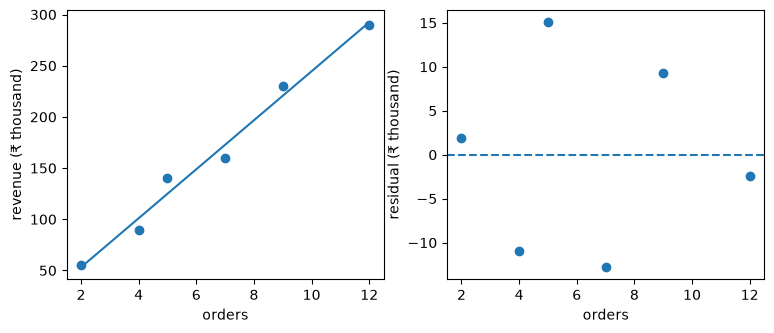

In [42]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3.5))
left.scatter(x, y)
left.plot(x, fitted)
left.set_xlabel("orders")
left.set_ylabel("revenue (₹ thousand)")
right.scatter(x, residuals)
right.axhline(0, linestyle="--")
right.set_xlabel("orders")
right.set_ylabel("residual (₹ thousand)")
plt.show()

- `plt.subplots(1, 2, figsize=(9, 3.5))` makes one row of two charts, unpacked into `left` and `right`; `figsize` is the width and height of the whole figure in inches.
- `left.plot(x, fitted)` joins the fitted values, which all lie on the line.
- `right.axhline(0, linestyle="--")` draws a dashed line at zero. A **residual plot** like this is the standard check of a straight-line fit. Residuals scattered evenly above and below zero are fine. A curve in them means the relationship isn't straight; a **fan**, residuals spreading wider as x grows, means the line is less reliable for big values of x.

### On Riverstone's customers

Now all 4,596 customers from section 22.5, with revenue in ₹ thousand so the numbers compare with the six:

In [43]:
by_customer["revenue_k"] = by_customer["revenue"] / 1000
fit_all = stats.linregress(by_customer["orders"], by_customer["revenue_k"])
print(f"slope {fit_all.slope:.2f} (₹ thousand per order), intercept {fit_all.intercept:.2f}, R² {fit_all.rvalue**2:.3f}")

slope 26.70 (₹ thousand per order), intercept -18.23, R² 0.838


- **Slope 26.70**: across Riverstone's customers, each extra order in the year goes with about ₹26,700 more revenue, a little above the mean order value, because customers who order often also tend to place bigger orders.
- **Intercept −18.23**: the line's revenue for a customer with 0 orders is minus ₹18,230, which is impossible. It isn't a finding; it's where the line happens to cross x = 0, far from any real customer (every customer here has at least one order). Don't read meaning into an intercept outside the data.
- **R² 0.838**: the number of orders accounts for about 84% of the variation in customers' revenue; the rest is mostly the size of their orders. It's r² again: 0.915² = 0.838.

One huge customer can tilt a line, so check how much the biggest ones matter. Refit without the top 1% by revenue (Chapter 21, section 21.4, on outliers):

In [44]:
cutoff = by_customer["revenue_k"].quantile(0.99)
typical = by_customer[by_customer["revenue_k"] <= cutoff]
fit_typical = stats.linregress(typical["orders"], typical["revenue_k"])
print(f"{len(by_customer) - len(typical)} customers removed; slope {fit_typical.slope:.2f}, R² {fit_typical.rvalue**2:.3f}")

46 customers removed; slope 25.77, R² 0.842


The slope moves by under ₹1,000 per order: the line doesn't depend on a few big customers. If it had moved a lot, you'd report both and say why.

### Reading it honestly

- **A line is not a cause.** Regression measures association, exactly like correlation; section 22.5's four questions (reverse causation, confounders, selection, chance) all still apply. "Each extra order goes with ₹26,700" doesn't mean that persuading a customer to split one order into two earns ₹26,700.
- **Don't extrapolate.** The line describes customers with 1 to 26 orders. What it says at 0 orders, or at 100, is a guess dressed as a number.
- **Check the influential points**, as above: refit without the extremes and compare.
- **y on x is not x on y.** Predicting revenue from orders and predicting orders from revenue give two different lines. Put the thing you want to explain on the y side.
- **Look at the residual plot** before trusting R².

### A 0/1 explanatory variable

x doesn't have to be a quantity. Make it 1 for Kolkata's orders and 0 for everyone else's, and regress delivery days on it. A column like this, which is 1 when something is true and 0 when it isn't, is called a **dummy variable**:

In [45]:
deliveries["is_kolkata"] = (deliveries["branch"] == "Kolkata").astype(int)
fit_k = stats.linregress(deliveries["is_kolkata"], deliveries["delivery_days"])
print(f"intercept {fit_k.intercept:.2f} days, slope {fit_k.slope:.2f} days")
print(deliveries.groupby("is_kolkata")["delivery_days"].mean().round(2).to_string())

intercept 4.09 days, slope 2.25 days
is_kolkata
0    4.09
1    6.33


- `(deliveries["branch"] == "Kolkata")` is True or False for every order; `.astype(int)` turns those into 1 and 0.
- With x only ever 0 or 1, the line has just two fitted values. The **intercept** is the mean for x = 0 (everyone except Kolkata, 4.09 days), and the **slope** is the *difference* between the two groups' means: Kolkata's deliveries take 2.25 days longer on average.

It's the same comparison as a t-test in regression clothing. The slope divided by its standard error is the test statistic, and it matches the ordinary (equal-spread) t-test exactly:

In [46]:
t_from_line = fit_k.slope / fit_k.stderr
t_test = stats.ttest_ind(deliveries.loc[deliveries["is_kolkata"] == 1, "delivery_days"],
                         deliveries.loc[deliveries["is_kolkata"] == 0, "delivery_days"])
print(f"t from the regression {t_from_line:.2f}; t from the t-test {t_test.statistic:.2f}")

t from the regression 73.07; t from the t-test 73.07


`stats.ttest_ind` without `equal_var=False` is the ordinary t-test, which assumes equal spreads, just as simple regression does. Chapter 30 uses this idea to put categories such as branch or segment into a regression.

### More than one x

Revenue depends on more than the number of orders. A regression can take several explanatory variables at once:

ŷ = a + b₁x₁ + b₂x₂ + …

Each b is then "the change in ŷ for one more unit of that x, **holding the others fixed**". That's **multiple regression**, and it's where Chapter 30 (regression to *explain*) and Chapter 37 (regression to *predict*) begin.

### Where it goes next

- **Chapter 30, section 30.11,** fits regressions with statsmodels' `smf.ols("y ~ x", data=...)`. Its summary table has the columns `coef`, `std err`, `t`, `P>|t|`, and `[0.025 0.975]`: this section's slope, standard error, slope ÷ standard error (23.93 ÷ 1.524 = 15.7 for the six customers), p-value, and 95% interval. It adds several x's, categories, and a regression for yes/no outcomes.
- **Chapter 31, section 31.3,** measures the effect of a change with a regression (difference-in-differences).
- **Chapter 37, section 37.1,** uses the same least-squares line to *predict* for customers it hasn't seen, with scikit-learn, and measures R² on data held back for testing.
- **Chapter 40** fits trend lines through time.

---

## Common mistakes

| Mistake | Symptom | Fix |
|---|---|---|
| Quoting a sample number with no interval | A 2-point "improvement" from 200 responses | Report the confidence interval every time |
| Reading an interval as a probability about the truth | "95% chance the mean is in here" | The method is 95% right; this interval either contains it or not |
| Confusing a confidence interval with a data range | "95% of orders are in this range" | Percentiles describe data; intervals describe estimates |
| Treating p as the probability the null is true | "3% chance there's no effect" | p is the probability of the data given the null |
| Treating p > 0.05 as proof of no effect | "No difference" from an underpowered test | State the minimum detectable effect |
| Choosing the metric after the result | Every test has a winner | Name the primary metric in advance |
| Peeking until significant | 20–25% false winners | Fix the sample size; test once at the end |
| Testing twenty slices and reporting one | A "finding" in exactly one segment | Correct for multiple comparisons; retest it |
| Removing outliers only when it helps | Results that move with the analyst's mood | Decide the rule first; report both ways |
| Randomizing by branch or day | The confounder is in the split | Randomize at the unit you measure |
| Running a test for three days | Day-of-week effects masquerade as lift | Whole business cycles |
| Reading correlation as causation | "Late deliveries cause churn" | Ask about reverse causation, confounders, selection |
| Comparing groups with different mixes | Simpson's paradox | Split by the confounder; standardize |
| Analysing only the survivors | "Our customers are all happy" | Ask who is missing from the table |
| Acting on the worst performers' rebound | "Coaching improved the bottom 10% by 18%" | Control group, or compare changes |
| Confusing significance with importance | p = 1e-12 on a 0.04-point lift | Effect size in business units |
| Comparing two significances | "Significant in North, not in South" | Test the difference between groups |
| Hiding the tests that failed | A suspiciously tidy story | Report what you tried |
| Extrapolating a line beyond the data | "A customer with no orders brings −₹18,230" | Use the line only within the range of x you fitted |
| Reading a slope as a cause | "Each extra order *earns* ₹26,700" | Say "goes with"; ask section 22.5's four questions |
| Swapping x and y | A different line, or a spreadsheet slope that makes no sense | y is what you explain; in `SLOPE`, y's range comes first |
| Trusting R² without a residual plot | A curved or fanning pattern hidden behind a high R² | Plot the residuals against x |

---

## In the real world: the transporter that wasn't better

In January 2026, Riverstone's logistics head proposed moving most upcountry deliveries to SwiftLine. The case was one number: 91.1% on-time against BlueCart's 79.7% across 11,600 Q4 deliveries. With that many deliveries, nobody doubted the number, and nobody needed to: it was right.

Meera asked one question before the contract went to procurement: *do the two transporters carry the same kind of work?*

They did not. SwiftLine ran 5,200 metro deliveries and 900 upcountry ones; BlueCart ran 1,100 metro and 4,400 upcountry. Split by route, the ranking flipped: BlueCart was better on metro (95.3% against 94.1%) and better upcountry (75.8% against 74.2%). Standardized to the company's actual route mix, BlueCart came out ahead overall.

The rest of the meeting was about two things, and both were more useful than the original proposal:

1. **Upcountry is the problem, not the transporter.** Both carriers lose about a quarter of upcountry deliveries against promise. Moving work between them changes the headline and not the customer experience.
2. **The headline number measures the mix.** If SwiftLine took the upcountry volume, its overall rate would fall toward BlueCart's, and the following quarter's review would "discover" that SwiftLine had deteriorated.

Riverstone kept both transporters, set route-level targets instead of company-level ones, and started reporting on-time rates standardized to a fixed route mix so that quarter-to-quarter comparisons meant something.

A postscript worth keeping. Three months later the upcountry rate improved by four points after a routing change. The logistics head asked whether it was real. It was: the improvement held in both transporters, in every month, and the 95% interval on the change (±1.6 points, from about 5,300 upcountry deliveries in each quarter) excluded zero comfortably. That's the same discipline pointed the other way — being able to say "this one *is* real" is exactly what makes the earlier "this one isn't" credible.

What made the difference:

- **One question:** are we comparing like with like?
- **Splitting by the obvious confounder** before accepting a difference.
- **Standardizing** so the comparison could be repeated fairly.
- **Being equally rigorous about the good news**, which is how you keep the right to question the bad.

---

## Project: audit three claims

**Goal:** take three claims that would pass unchallenged in a meeting, and test each one properly.

### Tools you'll need

- **Python 3.14** in your Chapter 17 environment, with `pandas`, `numpy`, `scipy`, `matplotlib`, and `statsmodels` (section 22.2). This chapter's code was checked on Python 3.11.15 with pandas 3.0.6, numpy 2.4.6, scipy 1.17.1, statsmodels 0.15.0, and matplotlib 3.10.8. Besides `proportions_ztest`, `statsmodels` has power calculators and multiple-comparison corrections.
- **A spreadsheet:** `NORM.S.INV`, `CONFIDENCE.T`, `T.INV.2T`, `CHISQ.TEST`, `SLOPE`, `INTERCEPT`, and `RSQ`; in Excel, the Analysis ToolPak's t-Test, ANOVA, Descriptive Statistics, and Regression.
- **Calculators** for sample size and A/B significance are everywhere online; use them for a second opinion, not as the method of record, and check whether they assume one- or two-sided tests (section 22.2).
- **Companion files (`companion/ch22/`):** `ab_test_2026.csv` (8,400 recipients across two variants), `transporters_q4_2025.csv` (11,600 deliveries by transporter and route, built to contain a genuine Simpson's paradox), and `ch22_by_hand.xlsx`. Both datasets are invented for this chapter; the delivery data comes from Chapter 21.

**Option A: your own workplace.** Three recent claims from a report, a review, or a vendor.

**Option B: Riverstone.** Use these three:

1. **"Variant B of the offer email is the better subject line."**
2. **"SwiftLine is our better transporter."**
3. **"Kolkata's on-time performance improved this quarter"** (use the festive months against the rest of 2025 as a stand-in).

**Steps, for each claim**

1. **Write the claim as a testable statement**, with a metric, a population, and a period.
2. **Check the data first** (Chapter 14): missing rows, duplicates, the period, and what's excluded.
3. **Estimate the effect and its confidence interval**, before any test.
4. **Run the appropriate test** and report the p-value alongside the effect.
5. **List the confounders** and split by at least one of them. Standardize if the mixes differ.
6. **Say what you could have detected**: compute the minimum detectable effect for the sample you have.
7. **Write the verdict in the section 22.9 template**, including what would change your mind.
8. **Recommend a decision**, and say what it would cost to be wrong.

**What good looks like:** claim 1 survives on its primary metric, opens (+3.45 points, 95% interval 1.6 to 5.3, p = 0.0003), and says nothing either way about orders (p = 0.29, minimum detectable effect about 0.95 points). Claim 2 reverses once route is controlled for. Claim 3 gets the honest treatment of a comparison that mixes seasonal effects with everything else.

**Stretch goals**

- Bootstrap the difference in median delivery days between two branches (resample 10,000 times) and compare with the t-test's interval.
- Design the order-rate test properly: how many recipients, over how long, and what you'd do at each outcome.
- Simulate your own peeking experiment with a real effect present, and measure how often early stopping overstates the effect size.
- Take any monthly KPI in your workplace, compute its month-to-month standard deviation, and work out how large a move has to be before it means anything.

---

## Timed challenge: forty-five minutes

Use `ab_test_2026.csv`, `transporters_q4_2025.csv`, and Chapter 21's delivery data. Answers at the end.

- **Level 1:** Open rate and order rate for each variant, with the difference in points.
- **Level 2:** A 95% confidence interval for each variant's open rate.
- **Level 3:** The p-value for the open-rate difference, and for the order-rate difference.
- **Level 4:** The minimum detectable effect for the order rate at 4,200 per variant.
- **Level 5:** On-time rate by transporter, overall and by route.
- **Level 6:** Each transporter's on-time rate standardized to the company's route mix.
- **Level 7:** A 95% interval for Kolkata's on-time rate, and for Mumbai HO's. Do they overlap?
- **Level 8:** One row per customer: fit revenue (₹ thousand) on orders. Report the slope, the intercept, and R².
- **Bonus:** Simulate 1,000 A/A tests on the email data (split variant A randomly in two) and count how often p < 0.05.

---

## Recap

- **Confidence intervals** turn sampling error into a range: estimate ± multiplier × standard error. The multiplier is 1.96 for a proportion and *t** (from the t-distribution, *n* − 1 degrees of freedom) for a mean. The method is right 95% of the time; a particular interval either contains the truth or doesn't. For small groups or rates near 0% or 100%, use the Wilson interval.
- **A p-value** is the probability of the data given the null, never the probability of the null. Report the effect and its interval first.
- **Choose the test by the data:** chi-square (or the equivalent z-test) for proportions, Welch's t-test for means, Mann-Whitney or a bootstrap for skewed data, paired tests for before-and-after. χ² adds up (observed − expected)² ÷ expected.
- **Design before you run:** one primary metric, a sample size from a power calculation, randomization at the unit you measure, whole business cycles, and a stopping rule, all written down first.
- **Peeking manufactures winners:** 5% false positives becomes 14% with five looks and 24% with twenty, in simulation on identical variants.
- **Multiple comparisons:** twenty tests at α = 0.05 give a 64% chance of at least one false positive. Correct (Bonferroni, or Benjamini-Hochberg when screening), or treat the finding as a hypothesis.
- **Correlation isn't causation:** consider reverse causation, confounders, selection, and chance. Spearman is the safer correlation on business data, and r near 0 can hide a curve.
- **Simpson's paradox** is common wherever groups do different work: BlueCart is better on both routes and worse overall, because it carries the hard routes. Standardize to compare fairly.
- **Survivorship and selection** decide who is in your data; **regression to the mean** explains most "the worst performers improved" stories.
- **Significance is not importance.** With half a million per variant, a 0.36-point difference has p ≈ 0.00003 (2.6 × 10⁻⁵) and means almost nothing.
- **Write it up plainly:** effect, interval, what you couldn't detect, the decision, and what would change your mind.
- **A regression line**, ŷ = a + b × x, chosen by least squares, says how much y changes per unit of x (the slope) and where the line crosses x = 0 (the intercept). R² is the share of y's variation the line explains. It's association, not cause, and it holds only within the range of the data.

---

## Key terms

sampling error · estimate · confidence interval · confidence level · margin of error · standard error · p̂ (p-hat) · t-distribution · degrees of freedom · normal approximation · Wilson interval · null hypothesis · alternative hypothesis · p-value · significance level (α) · effect size · one-sided test · two-sided test · observed and expected counts · chi-square test · Yates' continuity correction · two-proportion z-test · statsmodels · Welch's t-test · Mann-Whitney U · bootstrap · resampling with replacement · paired test · ANOVA · type I error · type II error · power · minimum detectable effect · A/B test · primary metric · randomization unit · stopping rule · pre-registration · peeking · sequential testing · multiple comparisons · family-wise error rate · Bonferroni correction · Benjamini-Hochberg · false discovery rate · p-hacking · garden of forking paths · correlation · correlation matrix · Pearson · Spearman · causation · reverse causation · confounder · Simpson's paradox · standardization · survivorship bias · selection bias · non-response bias · regression to the mean · control group · practical significance · regression · simple linear regression · response (dependent) variable · explanatory (independent) variable · slope · intercept · fitted value · residual · least squares · R² (coefficient of determination) · residual plot · extrapolation · dummy (0/1) variable · multiple regression

*(All terms are defined in the Glossary, Appendix A.)*

---

## Check yourself

- [ ] You can compute a 95% interval for a proportion by hand, in a spreadsheet, and in Python, and say what it means without overclaiming.
- [ ] You can say why a mean's interval uses the t-distribution, and what *n* − 1 degrees of freedom are.
- [ ] You can state a null hypothesis, compute χ² for a 2×2 table by hand, and choose the right test for two proportions, two means, and skewed data.
- [ ] You lead with effect size and interval, and treat p as supporting evidence.
- [ ] You compute the sample size before running a test, and the minimum detectable effect after.
- [ ] You fix the stopping rule in advance and can explain why peeking inflates false positives.
- [ ] You correct, or at least disclose, when you've tested many things.
- [ ] You ask what else could explain a correlation, and name the likely confounders.
- [ ] You check whether a group comparison is comparing like with like, and standardize when it isn't.
- [ ] You can spot survivorship, selection, and regression to the mean in someone else's chart.
- [ ] You can say whether an effect matters to the business, not only whether it's significant.
- [ ] You write results with the effect, the interval, the decision, and what would change your mind.
- [ ] You can compute a slope and intercept by hand, say what each means in rupees, and read R² and a residual plot.

---

## Exercises

### Warm-up

1. Rewrite each without overclaiming: (a) "There's a 95% chance the true on-time rate is between 81.4% and 82.1%." (b) "p = 0.30, so the two subject lines are the same." (c) "p = 0.001, so the effect is large."
2. A survey of 250 customers finds 71% would recommend Riverstone. Work out the 95% interval by hand, check it in a spreadsheet, and say how you'd present the number to a manager.
3. Why is a confidence interval not the same as the range that 95% of orders fall in?
4. You run a test for four days and see a 6% lift with p = 0.04. Give three reasons not to announce it yet.
5. Name three confounders that could explain "customers who receive our newsletter order more".
6. What is the minimum detectable effect, and why does it matter more than the p-value in a test that found nothing?
7. A line fitted to six customers says revenue (₹ thousand) = 5.28 + 23.93 × orders. Say in words what 23.93 and 5.28 mean, and why you shouldn't quote 5.28 as "what a customer with no orders spends".

### Core

8. Compute open rate, order rate, and revenue per recipient for each variant, with a 95% interval for each rate.
9. Test the open-rate difference with a chi-square test and with a two-proportion z-test. Do they agree?
10. Compute the 95% interval for the *difference* in open rates. Does it exclude zero?
11. Test the order-rate difference. What's the p-value, and what's the largest effect you could have ruled out?
12. How many recipients per variant would you need to detect a 0.5-point lift on a 2% order rate, at 80% power?
13. Test whether Mumbai HO and Bengaluru differ in mean delivery days (Welch) and in distribution (Mann-Whitney). Report the effect in days.
14. Compute the on-time rate and its 95% interval for each branch. Which pairs of branches have non-overlapping intervals?
15. Reproduce the Simpson's paradox table, then standardize both transporters to the company route mix. State the conclusion in one sentence.
16. Simulate the peeking experiment with 1, 3, 10, and 30 checkpoints. Plot the false-positive rate.
17. Run 1,000 A/A tests by randomly splitting variant A's recipients in two. How often is p < 0.05, and is that what you expected?
18. Compute the correlation between orders and average delivery days per customer, with Pearson and Spearman. What would you need to claim causation?
19. Split the delivery data into festive (October–November) and the rest. Is Kolkata's on-time rate different, and what confounds the comparison?
20. Bootstrap the difference in median delivery days between Delhi and Kolkata (10,000 resamples) and report a 95% interval.
21. Demonstrate regression to the mean the other way round: take the 100 customers with the lowest average delivery time in the first half of 2025 (among those with at least three orders in each half), and report their average in the second half.
22. Write up the A/B test in the section 22.9 template, in under 200 words.
23. Five customers placed 2, 4, 6, 8, and 10 orders and brought ₹50, 80, 120, 130, and 170 thousand. By hand, find the slope, the intercept, the residuals, and R². Then check with `SLOPE`, `INTERCEPT`, and `RSQ`.
24. Fit revenue (₹ thousand) on orders for all customers with `stats.linregress`. Then list the five customers with the largest positive residuals. What do they have in common?
25. Regress delivery days on a 0/1 dummy for Kolkata. Check that the intercept and slope match the two groups' means.
26. Take a claim from your own workplace and test it with steps 1–8 of the project.

### Stretch

27. Implement a Bonferroni and a Benjamini-Hochberg correction for a list of 12 p-values, and compare which survive.
28. Compute the power of the order-rate test as actually run (4,200 per variant, observed rates). What does that say about its conclusion?
29. Build a simple sequential test: check every 500 recipients but require p < 0.005 to stop early. Simulate its false-positive rate against the naive version.
30. Using only the delivery data, construct your own Simpson's paradox by choosing a grouping and a confounder. Then explain why it happens.
31. Regress delivery days on order value, order by order. Report the slope, its p-value, and R². Is the relationship "significant"? Does it matter?

### Think about it

32. A vendor says their tool "improved conversion by 14% for our clients". What do you ask?
33. Your A/B test shows a 0.4-point lift with p = 0.19. The sponsor wants to ship it because "it's positive". What do you say?
34. Is it ever right to act on a result that isn't statistically significant?

---

## Answers

**1.** (a) "If we repeated this sampling many times, 95% of the intervals built this way would contain the true rate; this one runs from 81.4% to 82.1%." (b) "We found no evidence of a difference; with this sample we could only have detected a difference of about 0.95 points or more." (c) "The difference is unlikely to be chance; it is 0.36 points, which is small."

**2.** Standard error = √(0.71 × 0.29 ÷ 250) = 0.0287; margin = 1.96 × 0.0287 = 0.0562; interval 0.71 ± 0.056 = **65.4% to 76.6%**. In a spreadsheet, `=SQRT(0.71*0.29/250)` and `=NORM.S.INV(0.975)` give the same pieces. Present it as "about 71%, give or take six points, from 250 customers".

**3.** The interval describes uncertainty about an *estimate* and shrinks with more data; the 95% range of the data describes the spread of orders and doesn't shrink at all. On Riverstone's order values the interval for the mean from 200 orders is a few thousand rupees wide; the range holding 95% of orders is tens of thousands.

**4.** Four days isn't a whole business cycle; p = 0.04 after repeated checking isn't 0.04; and a 6% lift early in a test is usually an overstatement, because tests that stop early stop on favourable noise.

**5.** Newsletter subscribers are already more engaged; they're often existing large customers; and they may have opted in at the point of a purchase. Each explains the association without the newsletter causing anything.

**6.** The smallest true effect your test had a good chance of detecting. In a null result it's the whole story: "no difference" with a minimum detectable effect of 5 points means you learned very little.

**7.** 23.93 is the slope: each extra order goes with about ₹23,930 more revenue in the year. 5.28 is the intercept: the line's value at 0 orders, ₹5,280. None of the six customers has 0 orders, so that's the line extended beyond the data, not a real customer's spending.

**8.** A: opens 23.50% (95% interval about 22.2% to 24.8%), orders 1.98%, revenue per recipient ₹483.70. B: opens 26.95% (25.6% to 28.3%), orders 2.31%, ₹530.31.

**9.** Both give p ≈ 0.0003; the chi-square statistic (13.27) is the square of the z statistic (3.64) for a 2×2 table, so they always agree.

**10.** The difference is +3.45 points, 95% interval about **+1.6 to +5.3 points**. It excludes zero, which is the same conclusion as the p-value in a more useful form.

**11.** p = 0.29. The 95% interval for the difference is about −0.29 to +0.95 points, so true effects larger than about +0.95 points are ruled out. Separately, the minimum detectable effect at 80% power is also about **0.95 points**, so any true difference smaller than that was likely to be missed.

**12.** About **13,800** per variant (13,809).

**13.** Mumbai HO's mean is 3.51 days against Bengaluru's 4.17, a difference of 0.66 days; both tests give p < 0.001. The medians are 3.2 and 3.8, so 0.6 days is the number to quote.

**14.** Mumbai HO 90.8% (90.3–91.2), Delhi 80.0% (79.3–80.8), Bengaluru 78.0% (77.3–78.7), Kolkata 68.1% (66.9–69.4). No pair overlaps. Delhi and Bengaluru come closest, about half a point apart (79.3 against 78.7).

**15.** Overall SwiftLine 91.1%, BlueCart 79.7%; by route BlueCart wins both (95.3 vs 94.1 metro, 75.8 vs 74.2 upcountry); standardized to the company mix the order reverses (BlueCart 86.4%, SwiftLine 85.0%). One sentence: *"BlueCart performs better on both route types; SwiftLine's higher overall rate reflects an easier route mix, not better service."*

**16.** The false-positive rate keeps rising with every extra look: roughly 5%, 11%, 19%, and 31% for 1, 3, 10, and 30 checkpoints in this setup (seed 2223, 1,500 pairs each). The exact numbers depend on the simulation, but the shape does not.

**17.** About **5%** of A/A tests come out "significant", which is exactly what α = 0.05 promises. Running this once is the fastest cure for trusting a single significant result.

**18.** The two correlate weakly at best (Pearson −0.09); Spearman and Pearson will differ because both variables are skewed. To claim causation you would need an experiment (randomly assigning delivery speed) or a natural one, plus control for branch, segment, and order size.

**19.** Kolkata's on-time rate is markedly lower in October and November (55.5% of 1,185 orders, against 71.5% of 4,441 in the other months). The comparison is confounded by volume (the festive peak), route mix, and the transporter mix, so a raw before-and-after overstates any process change.

**20.** Resample each branch's delivery days 10,000 times, take the difference of medians each time, and report the 2.5th and 97.5th percentiles. Delhi's median is 4.4 days and Kolkata's 5.7; the interval is comfortably above zero, about 1.2 to 1.4 days.

**21.** Of the 2,800 customers with at least three orders in each half, the 100 fastest averaged 2.46 days in the first half and 3.66 days in the second, while everyone went from 4.14 to 4.54. The fastest got slower by far more than the company did: the extremes regress, in both directions. That's the null result you must be able to produce before believing any "we fixed the worst performers" claim.

**22.** See the template in section 22.9; the numbers are in answers 8 to 11. The primary metric is the open rate.

**23.** x̄ = 6 and ȳ = 110. x − x̄: −4, −2, 0, 2, 4; y − ȳ: −60, −30, 10, 20, 60. Σ(x − x̄)(y − ȳ) = 240 + 60 + 0 + 40 + 240 = 580; Σ(x − x̄)² = 40. Slope b = 580 ÷ 40 = **14.5** (₹14,500 per order); intercept a = 110 − 14.5 × 6 = **23**. Fitted values 52, 81, 110, 139, 168; residuals −2, −1, 10, −9, 2 (they add to 0). SS<sub>res</sub> = 4 + 1 + 100 + 81 + 4 = 190; SS<sub>tot</sub> = 3,600 + 900 + 100 + 400 + 3,600 = 8,600; R² = 1 − 190 ÷ 8,600 = **0.978**. `SLOPE`, `INTERCEPT`, and `RSQ` give 14.5, 23, and 0.978.

**24.** Slope 26.70 (₹ thousand per order), intercept −18.23, R² 0.838. The five largest positive residuals are customers 3497, 1423, 3578, 1562, and 3252, each bringing ₹3.2–4.0 lakh more than their order count predicts. They place unusually large orders: the line explains revenue by the *number* of orders, so it misses customers whose orders are big.

**25.** Intercept 4.09 days (the mean for every branch except Kolkata); slope 2.25 days, so Kolkata's mean is 4.09 + 2.25 = 6.33 days. The groupby means are 4.09 and 6.33: the slope is the difference in means.

**26.** The point of the exercise is the write-up, not the test: a claim, a metric, an interval, a confounder you checked, and a decision.

**27.** With Bonferroni at 12 tests, only p < 0.0042 survives; Benjamini-Hochberg keeps more of the borderline ones by controlling the false discovery rate instead of the family-wise error rate. Use Bonferroni when a false positive is expensive, BH when you're screening.

**28.** Power for the observed 0.33-point difference at 4,200 per variant is about 18%, which is why "no significant difference" is uninformative here: the test was never likely to detect an effect of that size.

**29.** The sequential version keeps the overall false-positive rate near 5% while allowing early stopping, at the cost of needing a larger effect to stop early. That trade — stricter threshold for the right to look — is what all sequential methods buy.

**30.** Any grouping where the mix differs works: branch and order size, month and segment, or customer type and product. It happens because the group with the harder mix is penalized by the overall average, and the fix is always the same: compare within strata, or standardize.

**31.** The slope is about 0.0000067 days per rupee (0.0067 days, about 10 minutes, per ₹1,000 of order value), with p ≈ 10⁻²⁹, and R² = 0.003. It's "significant" only because there are 45,040 orders; order value explains 0.3% of the variation in delivery time, and ten minutes per ₹1,000 changes no decision. Section 22.8's lesson, in regression form.

**32.** From what baseline, over what period, on what population? Was it a controlled test or a before-and-after? How many clients, and were the ones who didn't improve included? Is 14% relative or absolute? And what's the confidence interval? "14% relative on a 1.2% baseline, uncontrolled, best five clients" is a different claim from the one being made.

**33.** Say what the data supports: the observed lift is 0.4 points, the interval includes zero and runs from about −0.2 to +1.0, so the result is consistent with anything from a small loss to a small gain. Then make it a business decision: if shipping costs nothing and the downside is bounded, ship it and keep measuring; if it costs real money, run the test to the sample size that could answer the question.

**34.** Yes, when the cost of acting is low and the cost of waiting is high, when the direction is consistent with other evidence, or when the decision has to be made anyway. What's not legitimate is *reporting* it as a proven effect. Say "consistent with a small improvement, not yet established", act if the economics justify it, and keep measuring.

**Checkpoint (end of Part A, section 22.4).** (1) A: 300 ÷ 1,000 = 30.0%; B: 345 ÷ 1,000 = 34.5%; difference 4.5 points. Standard error of the difference = √(0.30 × 0.70 ÷ 1,000 + 0.345 × 0.655 ÷ 1,000) = √0.000436 = 0.0209; margin 1.96 × 0.0209 = 0.041; interval **0.4 to 8.6 points**, just above zero. (2) Observed: A 300 replied, 700 didn't; B 345 and 655. Pooled reply rate 645 ÷ 2,000 = 32.25%, so each version expects 322.5 replies and 677.5 non-replies. χ² = 22.5² ÷ 322.5 + 22.5² ÷ 677.5 + 22.5² ÷ 322.5 + 22.5² ÷ 677.5 = 1.570 + 0.747 + 1.570 + 0.747 = **4.63**, above 3.84, so p is under 0.05. (3) `chi2_contingency([[300, 700], [345, 655]], correction=False)` gives χ² = 4.63 and p = 0.031.

**Timed challenge answers.** Level 1: A 23.50% opens and 1.98% orders; B 26.95% and 2.31%; differences +3.45 and +0.33 points. Level 2: A about 22.2–24.8%, B about 25.6–28.3%. Level 3: opens p = 0.0003, orders p = 0.29. Level 4: about 0.95 points. Level 5: SwiftLine 91.1% overall (94.1% metro, 74.2% upcountry), BlueCart 79.7% overall (95.3% metro, 75.8% upcountry). Level 6: standardized to the company mix, BlueCart 86.4% is ahead of SwiftLine 85.0%. Level 7: Kolkata 66.9–69.4%, Mumbai HO 90.3–91.2%: nowhere near overlapping. Level 8: slope 26.70 (₹ thousand per order), intercept −18.23, R² 0.838. Bonus: about 5% of the A/A tests come out significant.

---

## Where this leads

- **Chapter 23, Business Acumen, KPIs & Metrics:** confirming that a KPI's move is real before diagnosing it.
- **Chapter 24, Requirements, Storytelling & Stakeholders:** presenting an uncertain result so that it's understood rather than smoothed away.
- **Chapter 30, Inference & Experiments, and Chapter 31, Causal Inference Without Experiments:** this chapter's ideas at full depth, including regression for inference, building on section 22.10. The overlap with this chapter is deliberate: Chapter 30 re-derives standard errors, tests, and power with more care.
- **Chapter 37, Supervised Learning Algorithms:** regression for prediction.
- **Chapter 40, Time Series & Forecasting:** prediction intervals, and the same humility applied to the future.
- **Chapter 64, Security, Privacy, Governance & Responsible AI:** responsible use of data, including selective reporting.
- **Part 4:** train/test splits, cross-validation, and overfitting are this chapter's ideas in a modelling coat.
- **Interview preparation:** Chapter 73, the Statistics, Probability & Experimentation Bank, covers p-values, A/B design, and "why might this result be wrong?", which is the most common senior-analyst interview question there is.